### Import

In [ ]:
%pip install "numpy<2" --upgrade
!pip install tqdm
%pip install opencv-python==4.8.1.78
%pip install seaborn

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


In [ ]:
os.environ["CUDA_LAUNCH_BLOCKING"] = "1"
!nvidia-smi

Wed Jan 28 19:11:43 2026       
+-----------------------------------------------------------------------------+
| NVIDIA-SMI 517.00       Driver Version: 517.00       CUDA Version: 11.7     |
|-------------------------------+----------------------+----------------------+
| GPU  Name            TCC/WDDM | Bus-Id        Disp.A | Volatile Uncorr. ECC |
| Fan  Temp  Perf  Pwr:Usage/Cap|         Memory-Usage | GPU-Util  Compute M. |
|                               |                      |               MIG M. |
|===============================+======================+======================|
|   0  NVIDIA GeForce ... WDDM  | 00000000:01:00.0 Off |                  N/A |
| N/A   46C    P0    22W /  N/A |      0MiB /  6144MiB |      0%      Default |
|                               |                      |                  N/A |
+-------------------------------+----------------------+----------------------+
                                                                               
+-------

### Lib

In [1]:
#Library
import torch
import os
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import numpy as np

import cv2
print(cv2.__version__)
import numpy
print(numpy.__version__)
print(torch.__version__)
print("Torch loaded successfully")

#Check CUDA Availibility
print("CUDA available:", torch.cuda.is_available())
print("GPU:", torch.cuda.get_device_name(0))

#Check CUDA Memory 
torch.cuda.empty_cache()
print("Allocated (MB):", torch.cuda.memory_allocated() / 1024**2)
print("Reserved  (MB):", torch.cuda.memory_reserved() / 1024**2)
print("Free (approx MB):",
      (torch.cuda.get_device_properties(0).total_memory - torch.cuda.memory_reserved()) / 1024**2)

#from google.colab import drive
#drive.mount('/content/drive')

4.8.1
1.26.4
2.0.1+cu117
Torch loaded successfully
CUDA available: True
GPU: NVIDIA GeForce GTX 1660 Ti
Allocated (MB): 0.0
Reserved  (MB): 0.0
Free (approx MB): 6143.6875


### Dataloader

In [2]:
import os
import re
import cv2
import torch
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from PIL import Image

base_directory = "D:\\PROJ\\Dataset"
image_extensions = (".jpg", ".jpeg", ".png")

sequence_info = []
# Loop through subjects
for subject in sorted(os.listdir(base_directory)):
    subject_path = os.path.join(base_directory, subject)
    if not os.path.isdir(subject_path):
        continue

    for category in ['nm', 'nm_flip', 'bg', 'cl']:
        category_path = os.path.join(subject_path, category)
        if not os.path.isdir(category_path):
            continue

        # Sorted frames for proper temporal order
        frames = sorted([os.path.join(category_path, f)
                         for f in os.listdir(category_path) if f.lower().endswith(image_extensions)])

        sequence_info.append({
            'subject': subject,
            'category': category,
            'frames': frames,
            'num_frames': len(frames)
        })
# Compute stats
frame_counts = [seq['num_frames'] for seq in sequence_info]
print("Min frames:", np.min(frame_counts))
print("Max frames:", np.max(frame_counts))
print("Median frames:", np.median(frame_counts))
print("Total sequences:", len(sequence_info))

# ------------------------------------------------------------------------------------------------------------------
# ------------------- PARAMETERS -----------------------------------------------------------------------------------------------
sequence_length = 25        # Was 10 — covers full gait cycle
image_size = (240, 240)     # Was 128 — matches EfficientNet-B1 native resolution
batch_size = 4              # Keep 4 if GPU memory is tight at 240px
stride = 10                 # Was 5 — with seq_len=20, gives good diversity
NUM_WORKERS = 0             # Keep 0 for stability
#------------------------------------------------------------------------------------------------------------------
#------------------------------------------------------------------------------------------------------------------


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
# ------------------- BASE DIRECTORY -------------------
image_extensions = (".jpg", ".jpeg", ".png")
# ------------------- COLLECT FILES -------------------
grouped_images = {'nm': [],'nm_flip': [], 'bg': [], 'cl': []}

for subject in sorted(os.listdir(base_directory)):
    subject_path = os.path.join(base_directory, subject)
    if not os.path.isdir(subject_path):
        continue

    for category in ['nm', 'nm_flip', 'bg', 'cl']:
        category_path = os.path.join(subject_path, category)
        if not os.path.isdir(category_path):
            continue

        files = sorted([
            os.path.join(category_path, f)
            for f in os.listdir(category_path)
            if f.lower().endswith(image_extensions)
        ])
        grouped_images[category].extend(files)

# ------------------- SPLIT DATA -------------------
training_files = grouped_images['nm']+ grouped_images['nm_flip']
testing_bg, validation_bg = train_test_split(grouped_images['bg'], test_size=0.5, random_state=42)
testing_cl, validation_cl = train_test_split(grouped_images['cl'], test_size=0.5, random_state=42)
# ------------------- PERSON MAP -------------------
all_subjects = sorted([f.split(os.sep)[-3] for f in training_files + testing_bg + testing_cl + validation_bg + validation_cl])
person_ids = sorted(list(set(all_subjects)))
person_map = {pid: idx for idx, pid in enumerate(person_ids)}
# ------------------- DATASET -------------------
class GaitDatasetCV(Dataset):
    def __init__(self, file_list, sequence_length=10, image_size=(128, 128), transform=None, stride=1):
        self.sequence_length = sequence_length
        self.image_size = image_size
        self.transform = transform
        self.stride = stride  # Stride for overlapping sequences
        self.sequences = []
        self.labels = []

        # Group by person
        person_groups = {}
        for path in file_list:
            person_id = path.split(os.sep)[-3]
            person_groups.setdefault(person_id, []).append(path)

        for person_id, paths in person_groups.items():
            paths = sorted(paths, key=lambda x: int(re.findall(r'\d+', os.path.basename(x))[-1]))
            label = person_map[person_id]

            # ✅ OVERLAPPING SEQUENCES: Use stride parameter
            for i in range(0, len(paths) - sequence_length + 1, stride):
                seq_paths = paths[i:i + sequence_length]
                self.sequences.append(seq_paths)
                self.labels.append(label)

    def __len__(self):
        return len(self.sequences)

    def __getitem__(self, idx):
        seq_paths = self.sequences[idx]
        imgs = []

        from PIL import Image
        for path in seq_paths:
            # Read as color (BGR), convert to RGB so pretrained EfficientNet gets 3 channels
            img = cv2.imread(path, cv2.IMREAD_COLOR)
            if img is None:
                # fallback to a zero image if read fails
                img = np.zeros((self.image_size[1], self.image_size[0], 3), dtype=np.uint8)
            else:
                img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

            img = cv2.resize(img, self.image_size)

            if self.transform:
                # transform expects PIL image or ndarray; convert to PIL for consistency
                img = Image.fromarray(img)
                img = self.transform(img)  # returns tensor (3,H,W)
            else:
                img = img.astype('float32') / 255.0
                img = torch.tensor(img).permute(2, 0, 1)  # (3,H,W)

            imgs.append(img)

        imgs = torch.stack(imgs)  # (sequence_length, 3, H, W)
        label = torch.tensor(self.labels[idx], dtype=torch.long)

        # ✅ Return CPU tensors only (no .to(device) here)
        return imgs, label

# ------------------- DATASETS -------------------
train_dataset = GaitDatasetCV(training_files, stride=stride)
test_bg_dataset = GaitDatasetCV(testing_bg, stride=stride)
test_cl_dataset = GaitDatasetCV(testing_cl, stride=stride)
val_bg_dataset = GaitDatasetCV(validation_bg, stride=stride)
val_cl_dataset = GaitDatasetCV(validation_cl, stride=stride)
# ------------------- DATALOADERS -------------------
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=False, num_workers=0, pin_memory=True)
test_bg_loader = DataLoader(test_bg_dataset, batch_size=batch_size, shuffle=False, num_workers=0, pin_memory=True)
test_cl_loader = DataLoader(test_cl_dataset, batch_size=batch_size, shuffle=False, num_workers=0, pin_memory=True)
val_bg_loader = DataLoader(val_bg_dataset, batch_size=batch_size, shuffle=False, num_workers=0, pin_memory=True)
val_cl_loader = DataLoader(val_cl_dataset, batch_size=batch_size, shuffle=False, num_workers=0, pin_memory=True)
# ------------------- EXAMPLE USAGE -------------------
# Move batches to GPU only in loop
for sequences, labels in train_loader:
    sequences = sequences.to(device)  # (batch, seq_len, 3, H, W)
    labels = labels.to(device)
    print("Batch sequences shape:", sequences.shape)
    print("Batch labels shape:", labels.shape)
    break
# ------------------- CHECK -------------------
print("Number of training sequences:", len(train_dataset))
print("Number of BG testing sequences:", len(test_bg_dataset))
print("Number of CL testing sequences:", len(test_cl_dataset))
print("Number of BG validation sequences:", len(val_bg_dataset))
print("Number of CL validation sequences:", len(val_cl_dataset))

Min frames: 114
Max frames: 300
Median frames: 248.0
Total sequences: 120
Batch sequences shape: torch.Size([4, 10, 3, 128, 128])
Batch labels shape: torch.Size([4])
Number of training sequences: 1373
Number of BG testing sequences: 322
Number of CL testing sequences: 325
Number of BG validation sequences: 321
Number of CL validation sequences: 330


### Model

In [3]:
import torch
import torch.nn as nn
from torchvision import models, transforms

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

efficientnet_feature_extractor = models.efficientnet_b1(weights=models.EfficientNet_B1_Weights.IMAGENET1K_V1)
efficientnet_feature_extractor.classifier = nn.Identity()   # remove classifier
efficientnet_feature_extractor = efficientnet_feature_extractor.to(DEVICE)
# Do not freeze the EfficientNet feature extractor globally; keep it trainable during model training.
# efficientnet_feature_extractor.eval()

efficientnet_feature_extractor.train()

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225])])
    

In [4]:
import torch
import torch.nn as nn

# ------------------- BiLSTMClassifier -------------------
class BiLSTMClassifier(nn.Module):
    def __init__(self, num_classes, external_cnn_features, hidden_size=256, num_layers=2, dropout=0.5):
        super(BiLSTMClassifier, self).__init__()
        # Use the provided external CNN feature extractor (e.g., EfficientNetB2)
        self.cnn_features = external_cnn_features
        self.cnn_output_dim = 1280 # OFR EFFB1 = 1280 / B4=1792 EfficientNetB2's output feature dim when classifier is removed
        self.hidden_size = hidden_size
        self.num_layers = num_layers

        # Bi-directional LSTM layer for sequence modeling
        self.lstm = nn.LSTM(
            input_size=self.cnn_output_dim,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            bidirectional=True,
            dropout=dropout if num_layers > 1 else 0 # Apply dropout only if num_layers > 1
        )

        # Classifier Head - connected after LSTM and pooling
        # Output of bidirectional LSTM is 2 * hidden_size
        self.classifier = nn.Linear(2 * hidden_size, num_classes)

    def forward(self, x):
        # x: (batch_size, sequence_length, C, H, W)
        batch_size, T, C, H, W = x.size()

        # Reshape to process each frame through CNN
        # Input to CNN is (batch_size * sequence_length, C, H, W)
        x_reshaped = x.view(batch_size * T, C, H, W)

        # Convert 1-channel input to 3-channel for EfficientNet if necessary
        if C == 1:
            x_reshaped = x_reshaped.repeat(1, 3, 1, 1) # Repeat grayscale channel 3 times

        # Pass through CNN features to get frame-level embeddings
        cnn_features = self.cnn_features(x_reshaped) # (batch_size * T, cnn_output_dim)

        # Reshape back to (batch_size, T, cnn_output_dim) for LSTM input
        cnn_features = cnn_features.view(batch_size, T, self.cnn_output_dim)

        # Pass frame embeddings through Bi-LSTM layer
        # lstm_output: (batch_size, T, 2 * hidden_size)
        # (h_n, c_n): final hidden and cell states
        lstm_output, _ = self.lstm(cnn_features)

        # For classification, average the LSTM outputs across the sequence length.
        # This captures information from all time steps in the sequence.
        pooled_output = torch.mean(lstm_output, dim=1) # (batch_size, 2 * hidden_size)

        # Pass through classifier
        logits = self.classifier(pooled_output) # (batch_size, num_classes)

        return logits

print("BiLSTMClassifier class defined.")

BiLSTMClassifier class defined.


In [5]:
import torch
import torch.nn as nn
from torch.optim import Adam
from torch.optim.lr_scheduler import ReduceLROnPlateau
from torch.cuda.amp import autocast, GradScaler
from tqdm import tqdm

# -------------------- Device & AMP --------------------
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
use_amp = True  # Enabled mixed precision
#scaler = torch.amp.GradScaler('cuda', enabled=use_amp) # Updated GradScaler initialization
scaler = GradScaler(enabled=use_amp)
# -------------------- Model --------------------
model = BiLSTMClassifier(
    num_classes=len(person_map),
    external_cnn_features=efficientnet_feature_extractor,
    hidden_size=512,        # Was 256 — less aggressive bottleneck
    num_layers=2,     # Example number of LSTM layers
    dropout=0.5       # Example dropout rate
).to(device)

# -------------------- Optimizer, Scheduler, Loss --------------------
optimizer = torch.optim.Adam(
    model.parameters(),
    lr=3e-4,
    weight_decay=1e-4
)

scheduler = ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=3)

criterion = nn.CrossEntropyLoss()
#optimizer = Adam(model.parameters(), lr=3e-4, weight_decay=1e-4)
#criterion = nn.CrossEntropyLoss()
# -------------------- Training Loop --------------------
def train_model(model, train_loader, val_bg_loader=None, val_cl_loader=None, epochs=35, max_grad_norm=1.0, current_epoch=1, total_epochs=35):
    # This function should only perform logic for ONE epoch, the outer loop will call it for each epoch.
    model.train()
    if hasattr(model, 'cnn_features'):
        model.cnn_features.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for sequences, labels in tqdm(train_loader, desc=f"Epoch {current_epoch}/{total_epochs} [Train]"):
        sequences, labels = sequences.to(device, dtype=torch.float32), labels.to(device, dtype=torch.long)
        optimizer.zero_grad()

        # Updated autocast usage
        with torch.amp.autocast('cuda', enabled=use_amp):
            outputs = model(sequences)
            loss = criterion(outputs, labels)

        if use_amp:
            scaler.scale(loss).backward()
            # Gradient clipping
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_grad_norm)
            scaler.step(optimizer)
            scaler.update()
        else:
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_grad_norm)
            optimizer.step()

        running_loss += loss.item() * sequences.size(0)
        _, predicted = outputs.max(1)
        correct += (predicted == labels).sum().item()
        total += labels.size(0)

    train_loss = running_loss / total
    train_acc = correct / total * 100
    print(f"Epoch {current_epoch} → Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.2f}%")

    # -------------------- Validation on BG --------------------
    val_bg_acc = 0.0
    if val_bg_loader is not None:
        model.eval()
        val_bg_loss = 0.0
        val_bg_correct = 0
        val_bg_total = 0

        with torch.no_grad():
            # Updated autocast usage
            with torch.amp.autocast('cuda', enabled=use_amp):
                for sequences, labels in tqdm(val_bg_loader, desc=f"Epoch {current_epoch}/{total_epochs} [Val BG]"):
                    sequences, labels = sequences.to(device, dtype=torch.float32), labels.to(device, dtype=torch.long)
                    outputs = model(sequences)
                    loss = criterion(outputs, labels)

                    val_bg_loss += loss.item() * sequences.size(0) # Accumulate loss
                    _, predicted = outputs.max(1)
                    val_bg_correct += (predicted == labels).sum().item() # Accumulate correct predictions
                    val_bg_total += labels.size(0) # Accumulate total samples

        val_bg_loss /= val_bg_total
        val_bg_acc = val_bg_correct / val_bg_total * 100
        print(f"             → Val BG Loss: {val_bg_loss:.4f}, Val BG Acc: {val_bg_acc:.2f}%")

        # -------------------- Adjust Learning Rate --------------------
        scheduler.step(val_bg_loss)

    # -------------------- Validation on CL --------------------
    val_cl_acc = 0.0
    if val_cl_loader is not None:
        model.eval()
        val_cl_loss = 0.0
        val_cl_correct = 0
        val_cl_total = 0

        with torch.no_grad():
            # Updated autocast usage
            with torch.amp.autocast('cuda', enabled=use_amp):
                for sequences, labels in tqdm(val_cl_loader, desc=f"Epoch {current_epoch}/{total_epochs} [Val CL]"):
                    sequences, labels = sequences.to(device, dtype=torch.float32), labels.to(device, dtype=torch.long)
                    outputs = model(sequences)
                    loss = criterion(outputs, labels)

                    val_cl_loss += loss.item() * sequences.size(0) # Accumulate loss
                    _, predicted = outputs.max(1)
                    val_cl_correct += (predicted == labels).sum().item() # Accumulate correct predictions
                    val_cl_total += labels.size(0) # Accumulate total samples

        val_cl_loss /= val_cl_total
        val_cl_acc = val_cl_correct / val_cl_total * 100
        print(f"             → Val CL Loss: {val_cl_loss:.4f}, Val CL Acc: {val_cl_acc:.2f}%")

        scheduler.step(val_cl_loss)

    return train_acc, val_bg_acc, val_cl_acc

### Training on BG/CL

In [6]:
# ==================== CONDITION-WISE SPLIT (Gait Standard) ====================
print("=" * 70)
print("CONDITION-WISE SPLIT: NM→Train | BG/CL split by frames per subject")
print("=" * 70)

# Group BG and CL files by subject
bg_by_subject = {}
cl_by_subject = {}

for f in grouped_images['bg']:
    subj = f.split(os.sep)[-3]
    bg_by_subject.setdefault(subj, []).append(f)

for f in grouped_images['cl']:
    subj = f.split(os.sep)[-3]
    cl_by_subject.setdefault(subj, []).append(f)

# Sort files within each subject (chronologically by frame number)
for subj in bg_by_subject:
    bg_by_subject[subj].sort(key=lambda x: int(re.findall(r'\d+', os.path.basename(x))[-1]))

for subj in cl_by_subject:
    cl_by_subject[subj].sort(key=lambda x: int(re.findall(r'\d+', os.path.basename(x))[-1]))

# Split each subject's BG/CL frames: first 50% → validation, last 50% → testing
val_bg_cond = []
test_bg_cond = []
val_cl_cond = []
test_cl_cond = []

for subj in sorted(bg_by_subject.keys()):
    bg_frames = bg_by_subject[subj]
    split_idx = len(bg_frames) // 2
    val_bg_cond.extend(bg_frames[:split_idx])
    test_bg_cond.extend(bg_frames[split_idx:])

for subj in sorted(cl_by_subject.keys()):
    cl_frames = cl_by_subject[subj]
    split_idx = len(cl_frames) // 2
    val_cl_cond.extend(cl_frames[:split_idx])
    test_cl_cond.extend(cl_frames[split_idx:])

# All NM frames for training
train_nm_cond = grouped_images['nm']+ grouped_images['nm_flip']

# Create datasets
train_dataset_cond = GaitDatasetCV(train_nm_cond, stride=stride)
val_bg_dataset_cond = GaitDatasetCV(val_bg_cond, stride=stride)
test_bg_dataset_cond = GaitDatasetCV(test_bg_cond, stride=stride)
val_cl_dataset_cond = GaitDatasetCV(val_cl_cond, stride=stride)
test_cl_dataset_cond = GaitDatasetCV(test_cl_cond, stride=stride)

# Create dataloaders
train_loader_cond = DataLoader(train_dataset_cond, batch_size=batch_size, shuffle=True, num_workers=0, pin_memory=True)
val_bg_loader_cond = DataLoader(val_bg_dataset_cond, batch_size=batch_size, shuffle=False, num_workers=0, pin_memory=True)
test_bg_loader_cond = DataLoader(test_bg_dataset_cond, batch_size=batch_size, shuffle=False, num_workers=0, pin_memory=True)
val_cl_loader_cond = DataLoader(val_cl_dataset_cond, batch_size=batch_size, shuffle=False, num_workers=0, pin_memory=True)
test_cl_loader_cond = DataLoader(test_cl_dataset_cond, batch_size=batch_size, shuffle=False, num_workers=0, pin_memory=True)

print(f"\n✅ Condition-Wise Split (Frame-Level within Subjects):")
print(f"  Train (All NM): {len(train_dataset_cond)} sequences")
print(f"  Val BG (first 50% of frames per subject): {len(val_bg_dataset_cond)} sequences")
print(f"  Test BG (last 50% of frames per subject): {len(test_bg_dataset_cond)} sequences")
print(f"  Val CL (first 50% of frames per subject): {len(val_cl_dataset_cond)} sequences")
print(f"  Test CL (last 50% of frames per subject): {len(test_cl_dataset_cond)} sequences")

print(f"\n📊 Example: Subject 01")
subject_01_bg = bg_by_subject.get('01', [])
subject_01_cl = cl_by_subject.get('01', [])
split_bg = len(subject_01_bg) // 2
split_cl = len(subject_01_cl) // 2
print(f"  BG frames: {len(subject_01_bg)} total")
print(f"    → Val: frames 1-{split_bg}")
print(f"    → Test: frames {split_bg+1}-{len(subject_01_bg)}")
print(f"  CL frames: {len(subject_01_cl)} total")
print(f"    → Val: frames 1-{split_cl}")
print(f"    → Test: frames {split_cl+1}-{len(subject_01_cl)}")
print("=" * 70)

CONDITION-WISE SPLIT: NM→Train | BG/CL split by frames per subject

✅ Condition-Wise Split (Frame-Level within Subjects):
  Train (All NM): 1373 sequences
  Val BG (first 50% of frames per subject): 324 sequences
  Test BG (last 50% of frames per subject): 325 sequences
  Val CL (first 50% of frames per subject): 332 sequences
  Test CL (last 50% of frames per subject): 332 sequences

📊 Example: Subject 01
  BG frames: 270 total
    → Val: frames 1-135
    → Test: frames 136-270
  CL frames: 260 total
    → Val: frames 1-130
    → Test: frames 131-260


In [ ]:
# ==================== BiLSTMClassifier CONDITION-WISE SPLIT (Gait Standard) ====================
print("\n" + "=" * 70)
print("TRAINING WITH CONDITION-WISE SPLIT (NM→Train | BG/CL by frames)")
print("=" * 70)

# Reinitialize model
model_cond = BiLSTMClassifier(
    num_classes=len(person_map),
    external_cnn_features=efficientnet_feature_extractor,
    hidden_size=512,
    num_layers=2,
    dropout=0.5
).to(device)

optimizer_cond = torch.optim.Adam(model_cond.parameters(), lr=3e-4, weight_decay=1e-4)
scheduler_cond = ReduceLROnPlateau(optimizer_cond, mode='min', factor=0.5, patience=3)

best_train_acc_cond = 0.0
best_bg_acc_cond = 0.0
best_cl_acc_cond = 0.0

test_epochs_cond = 30

for epoch in range(test_epochs_cond):
    current_epoch = epoch + 1

    # Training on all NM
    model_cond.train()
    running_loss = 0.0
    correct = 0
    total = 0

    model_cond.train()
    if hasattr(model_cond, 'cnn_features'):
        model_cond.cnn_features.train()

    for sequences, labels in tqdm(train_loader_cond, desc=f"Epoch {current_epoch}/{test_epochs_cond} [Train NM]"):
        sequences, labels = sequences.to(device, dtype=torch.float32), labels.to(device, dtype=torch.long)
        optimizer_cond.zero_grad()
        with torch.amp.autocast('cuda', enabled=use_amp):
            outputs = model_cond(sequences)
            loss = criterion(outputs, labels)

        # Using the existing scaler for AMP if enabled
        if use_amp:
            scaler.scale(loss).backward()
            scaler.unscale_(optimizer_cond)
            torch.nn.utils.clip_grad_norm_(model_cond.parameters(), 1.0)
            scaler.step(optimizer_cond)
            scaler.update()
        else:
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model_cond.parameters(), 1.0)
            optimizer_cond.step()

        running_loss += loss.item() * sequences.size(0)
        _, predicted = outputs.max(1)
        correct += (predicted == labels).sum().item()
        total += labels.size(0)

    train_loss = running_loss / total
    train_acc = correct / total * 100
    print(f"Epoch {current_epoch} → Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.2f}%")

    # Validation on BG (first 50% of frames)
    model_cond.eval()
    val_bg_loss = 0.0
    val_bg_correct = 0
    val_bg_total = 0

    with torch.no_grad():
        with torch.amp.autocast('cuda', enabled=use_amp):
            for sequences, labels in tqdm(val_bg_loader_cond, desc=f"Epoch {current_epoch}/{test_epochs_cond} [Val BG]"):
                sequences, labels = sequences.to(device, dtype=torch.float32), labels.to(device, dtype=torch.long)
                outputs = model_cond(sequences)
                loss = criterion(outputs, labels)
                val_bg_loss += loss.item() * sequences.size(0)
                _, predicted = outputs.max(1)
                val_bg_correct += (predicted == labels).sum().item()
                val_bg_total += labels.size(0)

    val_bg_loss /= val_bg_total
    val_bg_acc = val_bg_correct / val_bg_total * 100
    print(f"             → Val BG Loss: {val_bg_loss:.4f}, Val BG Acc: {val_bg_acc:.2f}%")
    scheduler_cond.step(val_bg_loss)

    # Validation on CL (first 50% of frames)
    val_cl_loss = 0.0
    val_cl_correct = 0
    val_cl_total = 0

    with torch.no_grad():
        with torch.amp.autocast('cuda', enabled=use_amp):
            for sequences, labels in tqdm(val_cl_loader_cond, desc=f"Epoch {current_epoch}/{test_epochs_cond} [Val CL]"):
                sequences, labels = sequences.to(device, dtype=torch.float32), labels.to(device, dtype=torch.long)
                outputs = model_cond(sequences)
                loss = criterion(outputs, labels)
                val_cl_loss += loss.item() * sequences.size(0)
                _, predicted = outputs.max(1)
                val_cl_correct += (predicted == labels).sum().item()
                val_cl_total += labels.size(0)

    val_cl_loss /= val_cl_total
    val_cl_acc = val_cl_correct / val_cl_total * 100
    print(f"             → Val CL Loss: {val_cl_loss:.4f}, Val CL Acc: {val_cl_acc:.2f}%")
    scheduler_cond.step(val_cl_loss)

    if train_acc > best_train_acc_cond:
        best_train_acc_cond = train_acc
    if val_bg_acc > best_bg_acc_cond:
        best_bg_acc_cond = val_bg_acc
        torch.save(model_cond.state_dict(), "best_model_bg.pth")
        print(f"  ✅ Best BG model saved at epoch {current_epoch} | BG Acc: {val_bg_acc:.2f}%")
    if val_cl_acc > best_cl_acc_cond:
        best_cl_acc_cond = val_cl_acc

print("\n" + "=" * 70)
print(f"RESULTS (Condition-Wise Split):")
print(f"  Best Train Acc: {best_train_acc_cond:.2f}%")
print(f"  Best Val BG Acc: {best_bg_acc_cond:.2f}%")
print(f"  Best Val CL Acc: {best_cl_acc_cond:.2f}%")
print("=" * 70)
print("\n✅ Key: Subject 01 BG frames 1-160 in validation")
print("✅ Same subject BG frames 161-320 in testing")


TRAINING WITH CONDITION-WISE SPLIT (NM→Train | BG/CL by frames)


Epoch 1/30 [Train NM]: 100%|██████████| 344/344 [07:06<00:00,  1.24s/it]


Epoch 1 → Train Loss: 0.6711, Train Acc: 84.12%


Epoch 1/30 [Val BG]: 100%|██████████| 81/81 [01:33<00:00,  1.15s/it]


             → Val BG Loss: 0.3673, Val BG Acc: 92.28%


...

Epoch 30 → Train Loss: 0.0011, Train Acc: 100.00%


Epoch 30/30 [Val BG]: 100%|██████████| 81/81 [01:30<00:00,  1.11s/it]


             → Val BG Loss: 0.2661, Val BG Acc: 94.14%


Epoch 30/30 [Val CL]: 100%|██████████| 83/83 [01:32<00:00,  1.11s/it]

             → Val CL Loss: 5.1991, Val CL Acc: 22.59%

RESULTS (Condition-Wise Split):
  Best Train Acc: 100.00%
  Best Val BG Acc: 94.75%
  Best Val CL Acc: 24.70%

✅ Key: Subject 01 BG frames 1-160 in validation
✅ Same subject BG frames 161-320 in testing


In [9]:
# ==================== TESTING ON TEST SET (Condition-Wise Split) ====================
print("\n" + "=" * 70)
print("TESTING ON TEST SET (Last 50% frames per subject)")
print("=" * 70)

from collections import Counter

def evaluate_subject_level(model, loader, person_map, device, use_amp=True):
    model.eval()
    subject_preds = {}   # {true_label: [list of predicted labels]}
    
    with torch.no_grad():
        for sequences, labels in loader:
            sequences = sequences.to(device, dtype=torch.float32)
            labels = labels.to(device)
            
            with torch.amp.autocast('cuda', enabled=use_amp):
                outputs = model(sequences)
            
            _, predicted = outputs.max(1)
            
            for pred, true in zip(predicted.cpu().numpy(), labels.cpu().numpy()):
                if true not in subject_preds:
                    subject_preds[true] = []
                subject_preds[true].append(pred)
    
    # Majority vote per subject
    correct = 0
    total = len(subject_preds)
    reverse_map = {v: k for k, v in person_map.items()}
    
    print("\n📋 Subject-Level Results:")
    for true_label in sorted(subject_preds.keys()):
        preds = subject_preds[true_label]
        majority_vote = Counter(preds).most_common(1)[0][0]
        is_correct = majority_vote == true_label
        correct += int(is_correct)
        status = "✅" if is_correct else "❌"
        subject_name = reverse_map.get(true_label, str(true_label))
        print(f"  {status} Subject {subject_name}: Predicted={reverse_map.get(majority_vote, majority_vote)}, "
              f"Votes={Counter(preds).most_common(3)}")
    
    print(f"\n🎯 Subject-Level Accuracy: {correct}/{total} ({correct/total*100:.1f}%)")
    return correct, total

model_cond.eval()

# Test on BG
test_bg_loss = 0.0
test_bg_correct = 0
test_bg_total = 0
test_bg_predictions = []
test_bg_labels_list = []

print("\nTesting on BG condition (last 50% of frames per subject)...")
with torch.no_grad():
    for sequences, labels in tqdm(test_bg_loader_cond, desc="Test BG"):
        sequences, labels = sequences.to(device, dtype=torch.float32), labels.to(device, dtype=torch.long)
        outputs = model_cond(sequences)
        loss = criterion(outputs, labels)

        test_bg_loss += loss.item() * sequences.size(0)
        _, predicted = outputs.max(1)
        test_bg_correct += (predicted == labels).sum().item()
        test_bg_total += labels.size(0)

        test_bg_predictions.extend(predicted.cpu().numpy())
        test_bg_labels_list.extend(labels.cpu().numpy())

test_bg_loss /= test_bg_total
test_bg_acc = test_bg_correct / test_bg_total * 100

print(f"Test BG Loss: {test_bg_loss:.4f}, Test BG Acc: {test_bg_acc:.2f}%")

# Test on CL
test_cl_loss = 0.0
test_cl_correct = 0
test_cl_total = 0
test_cl_predictions = []
test_cl_labels_list = []

print("Testing on CL condition (last 50% of frames per subject)...")
with torch.no_grad():
    for sequences, labels in tqdm(test_cl_loader_cond, desc="Test CL"):
        sequences, labels = sequences.to(device, dtype=torch.float32), labels.to(device, dtype=torch.long)
        outputs = model_cond(sequences)
        loss = criterion(outputs, labels)

        test_cl_loss += loss.item() * sequences.size(0)
        _, predicted = outputs.max(1)
        test_cl_correct += (predicted == labels).sum().item()
        test_cl_total += labels.size(0)

        test_cl_predictions.extend(predicted.cpu().numpy())
        test_cl_labels_list.extend(labels.cpu().numpy())

test_cl_loss /= test_cl_total
test_cl_acc = test_cl_correct / test_cl_total * 100

print(f"Test CL Loss: {test_cl_loss:.4f}, Test CL Acc: {test_cl_acc:.2f}%")

# Summary
print("\n" + "=" * 70)
print("TESTING SUMMARY (Condition-Wise Split)")
print("=" * 70)
print(f"\n📊 TRAINING SET (NM):")
print(f"  Best Accuracy: {best_train_acc_cond:.2f}%")

print(f"\n📊 VALIDATION SET (First 50% frames per subject):")
print(f"  BG Accuracy: {best_bg_acc_cond:.2f}%")
print(f"  CL Accuracy: {best_cl_acc_cond:.2f}%")

print(f"\n📊 TEST SET (Last 50% frames per subject):")
print(f"  BG Accuracy: {test_bg_acc:.2f}%")
print(f"  CL Accuracy: {test_cl_acc:.2f}%")

print(f"\n📈 Generalization Analysis:")
print(f"  Val BG → Test BG gap: {best_bg_acc_cond - test_bg_acc:.2f}% (gap should be small)")
print(f"  Val CL → Test CL gap: {best_cl_acc_cond - test_cl_acc:.2f}% (gap should be small)")

print("\n" + "=" * 70)

# Per-class accuracy for BG
print("\n📋 Per-Class Test Accuracy (BG):")
from collections import Counter
test_bg_pred_arr = np.array(test_bg_predictions)
test_bg_label_arr = np.array(test_bg_labels_list)

for class_id in sorted(set(test_bg_label_arr)):
    mask = test_bg_label_arr == class_id
    class_acc = (test_bg_pred_arr[mask] == test_bg_label_arr[mask]).mean() * 100
    subject_name = [k for k, v in person_map.items() if v == class_id][0]
    print(f"  Subject {subject_name}: {class_acc:.2f}% ({mask.sum()} samples)")

print("\n📋 Per-Class Test Accuracy (CL):")
test_cl_pred_arr = np.array(test_cl_predictions)
test_cl_label_arr = np.array(test_cl_labels_list)

for class_id in sorted(set(test_cl_label_arr)):
    mask = test_cl_label_arr == class_id
    class_acc = (test_cl_pred_arr[mask] == test_cl_label_arr[mask]).mean() * 100
    subject_name = [k for k, v in person_map.items() if v == class_id][0]
    print(f"  Subject {subject_name}: {class_acc:.2f}% ({mask.sum()} samples)")

print("=" * 70)

# ==================== SUBJECT-LEVEL MAJORITY VOTING EVALUATION ====================
print("\n=== BG Subject-Level (Test Set) ===")
evaluate_subject_level(model_cond, test_bg_loader_cond, person_map, device)

print("\n=== CL Subject-Level (Test Set) ===")
evaluate_subject_level(model_cond, test_cl_loader_cond, person_map, device)


TESTING ON TEST SET (Last 50% frames per subject)

Testing on BG condition (last 50% of frames per subject)...


Test BG:   0%|          | 0/82 [00:00<?, ?it/s]

Test BG: 100%|██████████| 82/82 [01:28<00:00,  1.08s/it]


Test BG Loss: 0.0737, Test BG Acc: 97.23%
Testing on CL condition (last 50% of frames per subject)...


Test CL: 100%|██████████| 83/83 [01:33<00:00,  1.13s/it]


Test CL Loss: 5.4210, Test CL Acc: 20.18%

TESTING SUMMARY (Condition-Wise Split)

📊 TRAINING SET (NM):
  Best Accuracy: 100.00%

📊 VALIDATION SET (First 50% frames per subject):
  BG Accuracy: 94.75%
  CL Accuracy: 24.70%

📊 TEST SET (Last 50% frames per subject):
  BG Accuracy: 97.23%
  CL Accuracy: 20.18%

📈 Generalization Analysis:
  Val BG → Test BG gap: -2.48% (gap should be small)
  Val CL → Test CL gap: 4.52% (gap should be small)


📋 Per-Class Test Accuracy (BG):
  Subject 01: 100.00% (13 samples)
  Subject 02: 100.00% (14 samples)
  Subject 03: 100.00% (12 samples)
  Subject 04: 100.00% (11 samples)
  Subject 05: 100.00% (13 samples)
  Subject 06: 100.00% (13 samples)
  Subject 07: 100.00% (12 samples)
  Subject 08: 100.00% (14 samples)
  Subject 09: 100.00% (13 samples)
  Subject 10: 100.00% (12 samples)
  Subject 11: 100.00% (13 samples)
  Subject 12: 100.00% (13 samples)
  Subject 13: 100.00% (7 samples)
  Subject 14: 85.71% (7 samples)
  Subject 15: 100.00% (15 samples)
 

(8, 30)

### EVALUATING TECHNIQUES

In [10]:
import numpy as np
from sklearn.manifold import TSNE
from collections import Counter
from sklearn.metrics import classification_report
import pandas as pd
import seaborn as sns
import torch
from matplotlib.lines import Line2D


FINAL EVALUATION WORKFLOW - LOAD BEST MODEL & RUN ALL 6 TECHNIQUES

[STEP 1/3] Loading best_model_bg.pth...
✅ Best model loaded successfully

[STEP 2/3] Running comprehensive inference on test sets...
Collecting: predictions, softmax probs, embeddings, subject votes...

  Processing BG test set...


    BG inference: 100%|██████████| 82/82 [01:35<00:00,  1.16s/it]


    ✅ BG | Frame Acc: 98.77% | Subject Acc: 100.00%
  Processing CL test set...


    CL inference: 100%|██████████| 83/83 [01:39<00:00,  1.20s/it]


    ✅ CL | Frame Acc: 18.67% | Subject Acc: 23.33%

✅ Inference complete. All data collected.

[STEP 3/3] Generating 6 evaluation visualizations...

  [01/06] Subject-condition profile...


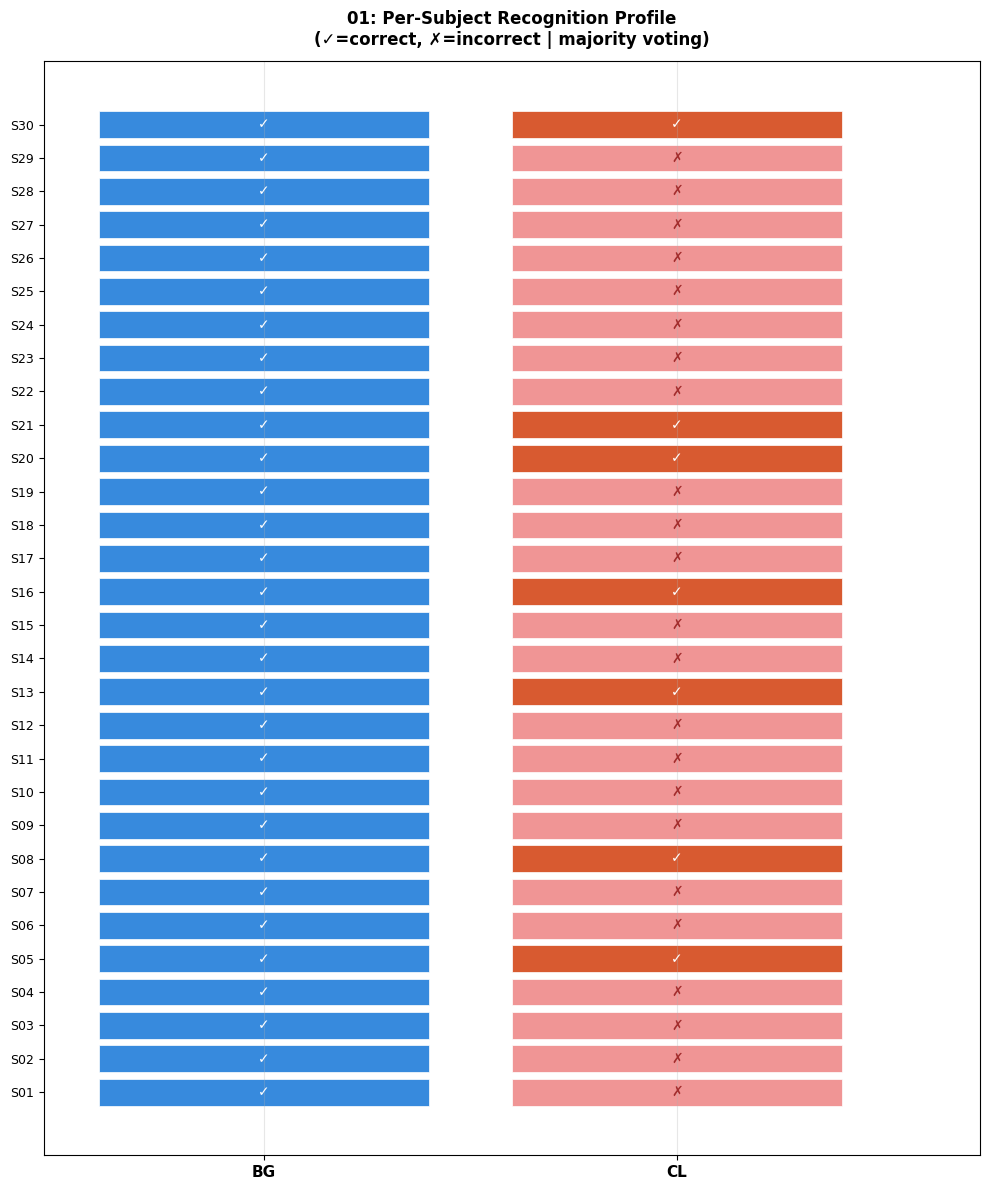

  [02/06] CMC (rank-k accuracy) curve with per-subject analysis...

RANK-K ACCURACY ANALYSIS - DETAILED WRITTEN RESULTS

CONDITION: BG (CLOTHING/BAG) - Per-Subject Rank-k Recognition

Subject      Rank-1       Rank-2       Rank-3       Rank-5       Status              
------------------------------------------------------------------------------------------
S01         ✓ Rank-1     ✓            ✓            ✓            🟢 Recognized        
S02         ✓ Rank-1     ✓            ✓            ✓            🟢 Recognized        
S03         ✓ Rank-1     ✓            ✓            ✓            🟢 Recognized        
S04         ✓ Rank-1     ✓            ✓            ✓            🟢 Recognized        
S05         ✓ Rank-1     ✓            ✓            ✓            🟢 Recognized        
S06         ✓ Rank-1     ✓            ✓            ✓            🟢 Recognized        
S07         ✓ Rank-1     ✓            ✓            ✓            🟢 Recognized        
S08         ✓ Rank-1     ✓            ✓     

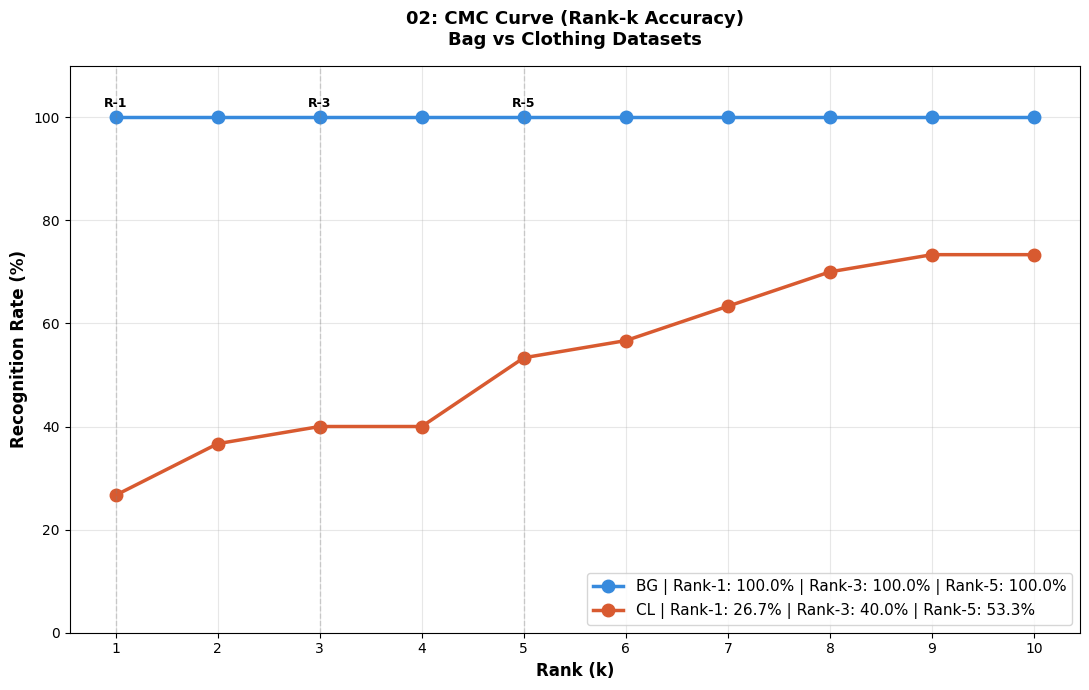

  [03/06] Confidence distribution...


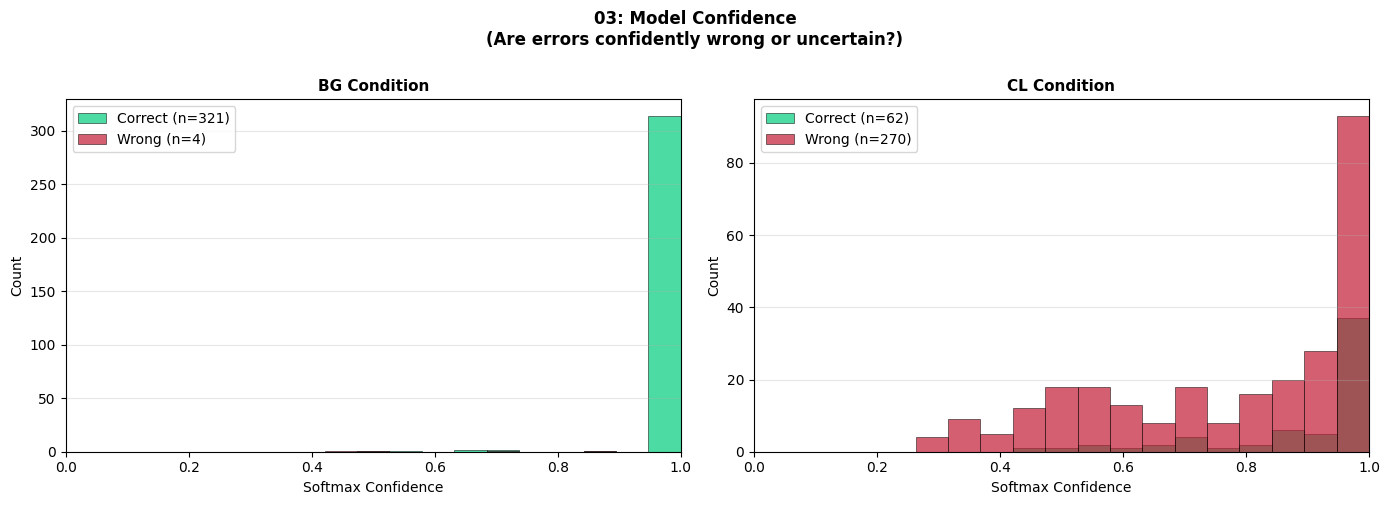

  [04/05] Per-subject vote breakdown (BG & CL)...


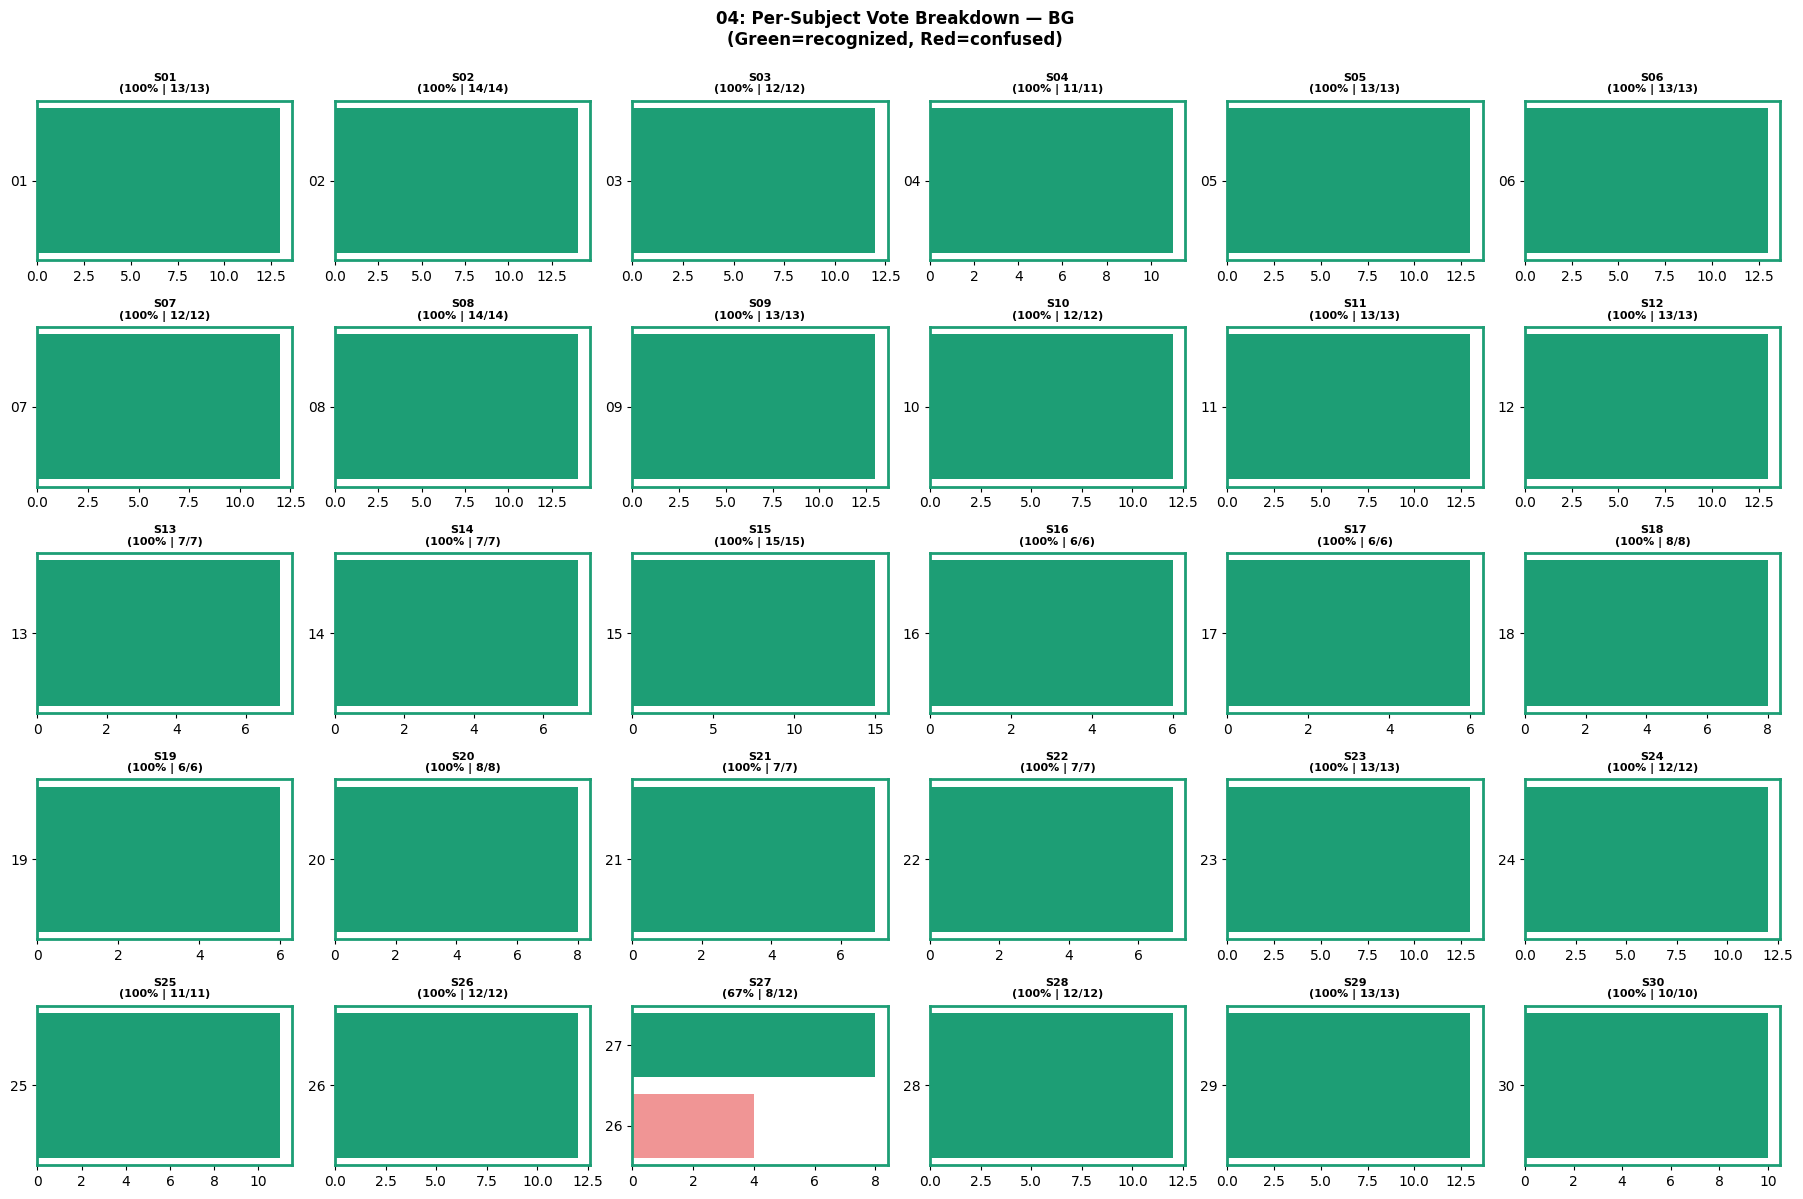

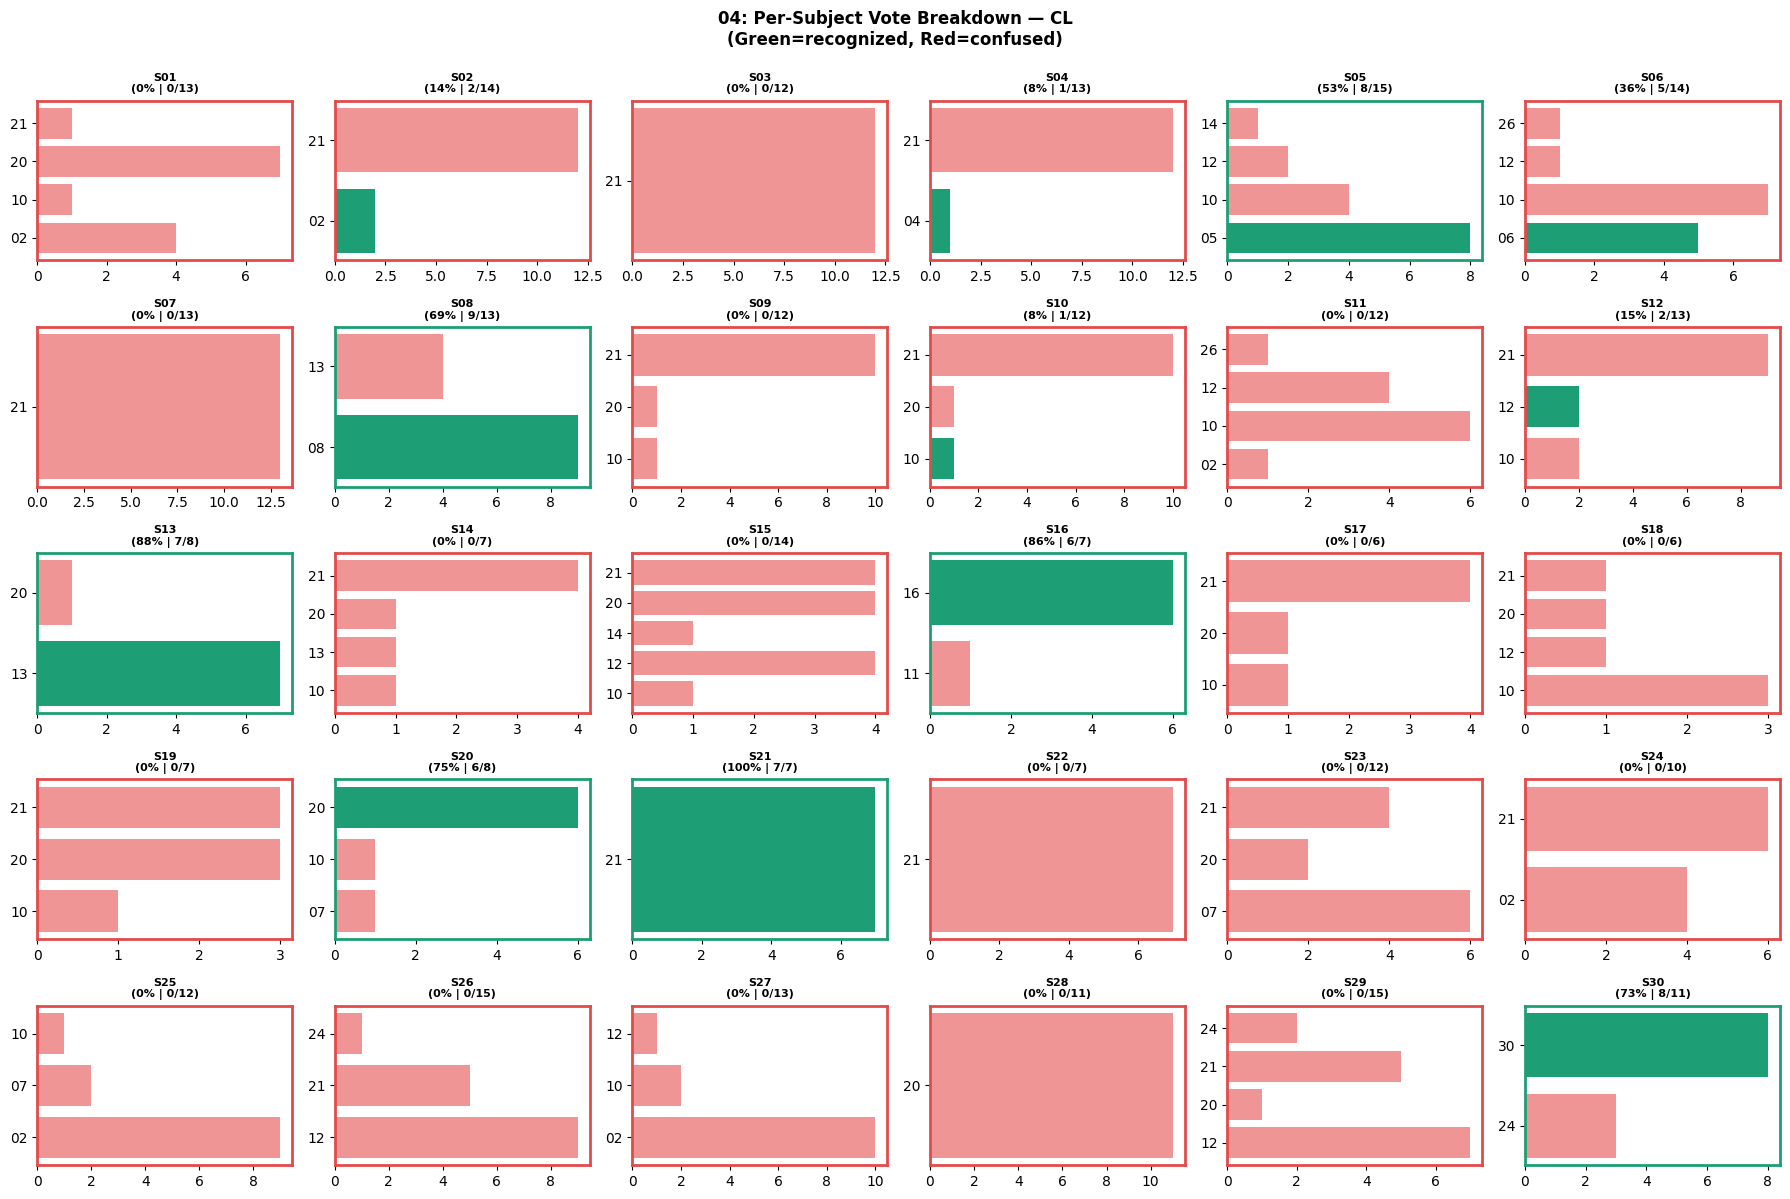

  [05/05] Per-subject F1 heatmap (BG & CL)...


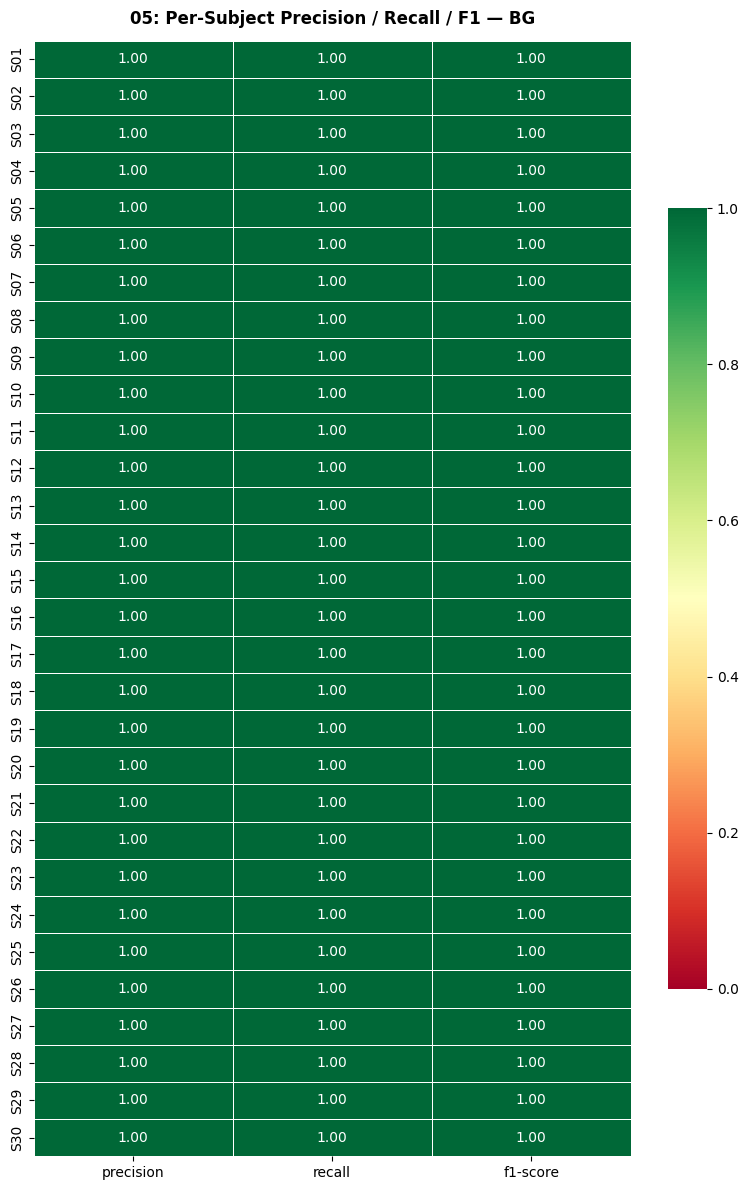

d:\PROJ\gpu_env\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
d:\PROJ\gpu_env\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
d:\PROJ\gpu_env\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


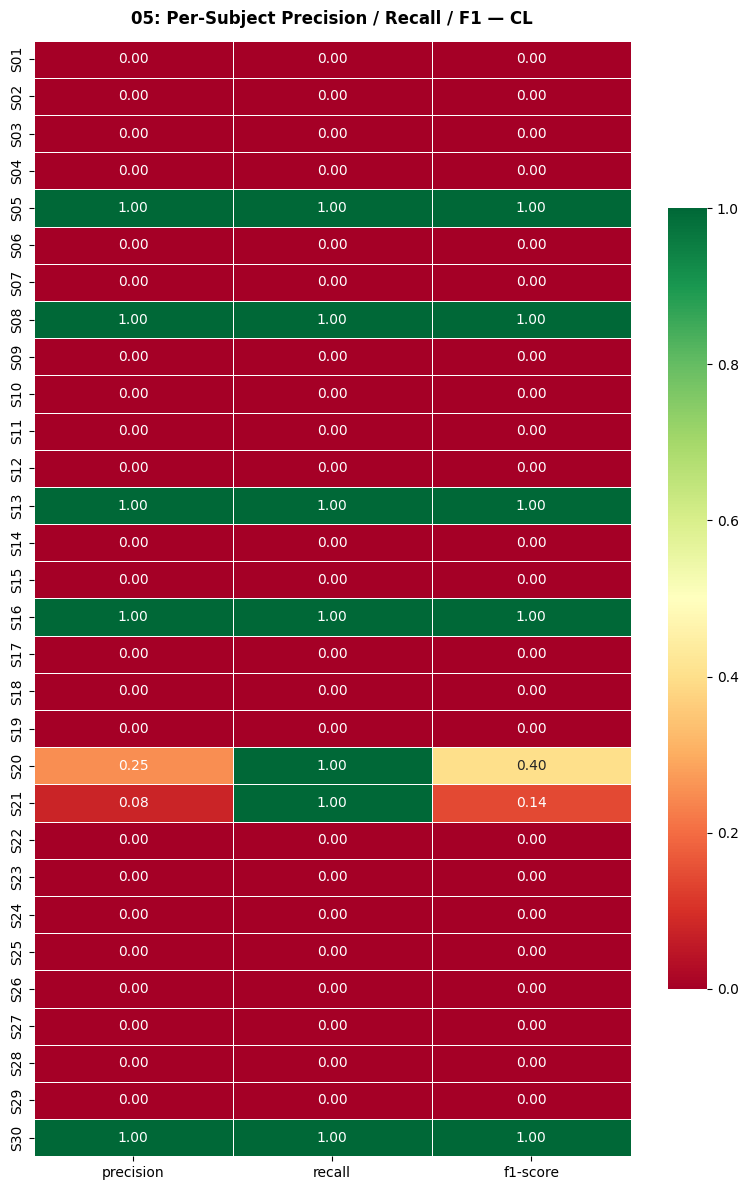


✅ ALL 5 EVALUATION TECHNIQUES COMPLETE

📊 Generated visualizations:
  ✅ 01_subject_condition_profile.png — 30/30 subject-by-subject breakdown
  ✅ 02_cmc_curve.png              — Rank-k accuracy (rank-1, rank-3, rank-5)
  ✅ 03_confidence_distribution.png — Error analysis (confident vs uncertain?)
  ✅ 04_vote_distribution_BG.png   — BG confusion analysis
  ✅ 04_vote_distribution_CL.png   — CL confusion analysis
  ✅ 05_per_subject_f1_BG.png      — BG precision/recall per subject
  ✅ 05_per_subject_f1_CL.png      — CL precision/recall per subject

All files ready for your FYP presentation!


In [28]:
# ==================== FINAL EVALUATION: LOAD BEST MODEL & RUN ALL 6 TECHNIQUES ====================
# After training is complete, run this cell to:
# 1. Load best_model_bg.pth
# 2. Run inference on BG and CL test sets
# 3. Generate all 6 evaluation visualizations for your FYP presentation

print("\n" + "=" * 80)
print("FINAL EVALUATION WORKFLOW - LOAD BEST MODEL & RUN ALL 6 TECHNIQUES")
print("=" * 80)

# ==================== STEP 1: LOAD BEST MODEL ====================
print("\n[STEP 1/3] Loading best_model_bg.pth...")
model_final = BiLSTMClassifier(
    num_classes=len(person_map),
    external_cnn_features=efficientnet_feature_extractor,
    hidden_size=512,
    num_layers=2,
    dropout=0.5
).to(device)

model_final.load_state_dict(torch.load("best_model_bg.pth"))
model_final.eval()
print("✅ Best model loaded successfully\n")

# ==================== STEP 2: COMPREHENSIVE INFERENCE ====================
print("[STEP 2/3] Running comprehensive inference on test sets...")
print("Collecting: predictions, softmax probs, embeddings, subject votes...\n")

def comprehensive_test_inference(model, loaders_dict, device, criterion, use_amp=True):
    """Collect ALL data needed for 6 evaluation techniques"""
    model.eval()
    results = {
        'BG': {'all_probs': [], 'all_preds': [], 'all_labels': [], 
               'subject_preds': {}, 'all_embeddings': [], 'losses': []},
        'CL': {'all_probs': [], 'all_preds': [], 'all_labels': [], 
               'subject_preds': {}, 'all_embeddings': [], 'losses': []}
    }
    
    with torch.no_grad():
        for cond, loader in loaders_dict.items():
            print(f"  Processing {cond} test set...")
            for sequences, labels in tqdm(loader, desc=f"    {cond} inference"):
                sequences = sequences.to(device, dtype=torch.float32)
                labels = labels.to(device)
                
                with torch.amp.autocast('cuda', enabled=use_amp):
                    outputs = model(sequences)
                    loss = criterion(outputs, labels)
                
                # Probabilities and predictions
                probs = torch.softmax(outputs, dim=1)
                _, preds = outputs.max(1)
                
                results[cond]['all_probs'].append(probs.cpu().numpy())
                results[cond]['all_preds'].extend(preds.cpu().numpy())
                results[cond]['all_labels'].extend(labels.cpu().numpy())
                results[cond]['losses'].append(loss.item())
                
                # Collect embeddings via hook
                embeddings = []
                def hook_fn(module, args):
                    embeddings.append(args[0].detach().cpu().numpy())
                
                hook = model.classifier.register_forward_pre_hook(hook_fn)
                _ = model(sequences)
                hook.remove()
                
                if embeddings:
                    results[cond]['all_embeddings'].append(embeddings[0])
                
                # Per-subject voting
                for pred, true in zip(preds.cpu().numpy(), labels.cpu().numpy()):
                    if true not in results[cond]['subject_preds']:
                        results[cond]['subject_preds'][true] = []
                    results[cond]['subject_preds'][true].append(pred)
            
            # Consolidate
            if results[cond]['all_embeddings']:
                results[cond]['all_embeddings'] = np.vstack(results[cond]['all_embeddings'])
            if results[cond]['all_probs']:
                results[cond]['all_probs'] = np.vstack(results[cond]['all_probs'])
            results[cond]['all_preds'] = np.array(results[cond]['all_preds'])
            results[cond]['all_labels'] = np.array(results[cond]['all_labels'])
            results[cond]['avg_loss'] = np.mean(results[cond]['losses'])
            
            # Compute accuracies
            frame_acc = (results[cond]['all_preds'] == results[cond]['all_labels']).mean() * 100
            subject_correct = sum(1 for true, votes in results[cond]['subject_preds'].items() 
                                 if Counter(votes).most_common(1)[0][0] == true)
            subject_total = len(results[cond]['subject_preds'])
            subject_acc = (subject_correct / subject_total * 100) if subject_total > 0 else 0
            
            print(f"    ✅ {cond} | Frame Acc: {frame_acc:.2f}% | Subject Acc: {subject_acc:.2f}%")
    
    return results

test_results = comprehensive_test_inference(
    model_final, 
    loaders_dict={'BG': test_bg_loader_cond, 'CL': test_cl_loader_cond},
    device=device,
    criterion=criterion,
    use_amp=use_amp
)

print("\n✅ Inference complete. All data collected.\n")

# ==================== STEP 3: GENERATE ALL 6 TECHNIQUES ====================
print("[STEP 3/3] Generating 6 evaluation visualizations...\n")

# TECHNIQUE 01: Subject-Condition Profile
print("  [01/06] Subject-condition profile...")
subjects = sorted(person_map.keys())
n_subj = len(subjects)
fig, ax = plt.subplots(figsize=(10, 12))

for i, subj in enumerate(subjects):
    for j, cond in enumerate(['BG', 'CL']):
        subject_idx = person_map[subj]
        votes = test_results[cond]['subject_preds'].get(subject_idx, [])
        is_correct = Counter(votes).most_common(1)[0][0] == subject_idx if votes else False
        color = {'BG': '#378ADD', 'CL': '#D85A30'}[cond] if is_correct else '#F09595'
        
        ax.broken_barh([(j * 1.5, 1.2)], (i - 0.4, 0.8), facecolors=color, edgecolors='white', linewidth=0.5)
        ax.text(j * 1.5 + 0.6, i, '✓' if is_correct else '✗', ha='center', va='center', 
               fontsize=10, fontweight='bold', color='white' if is_correct else '#A32D2D')

ax.set_yticks(range(n_subj))
ax.set_yticklabels([f"S{s}" for s in subjects], fontsize=9)
ax.set_xticks([0.6, 2.1])
ax.set_xticklabels(['BG', 'CL'], fontsize=11, fontweight='bold')
ax.set_title('01: Per-Subject Recognition Profile\n(✓=correct, ✗=incorrect | majority voting)', 
            fontsize=12, fontweight='bold', pad=12)
ax.set_xlim([-0.2, 3.2])
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig('01_subject_condition_profile.png', dpi=150, bbox_inches='tight')
plt.show()

# TECHNIQUE 02: CMC Curve with Detailed Written Results
print("  [02/06] CMC (rank-k accuracy) curve with per-subject analysis...")

cmc_results = {}
reverse_map = {v: k for k, v in person_map.items()}

# Generate CMC data for both BG and CL
for cond in ['BG', 'CL']:
    all_probs = test_results[cond]['all_probs']
    all_labels = test_results[cond]['all_labels']
    subject_probs = {}
    
    for i, label in enumerate(all_labels):
        if label not in subject_probs:
            subject_probs[label] = []
        subject_probs[label].append(all_probs[i])
    
    # Compute per-subject rank-k recognition
    subject_ranks = {}  # {subject_id: rank_at_which_recognized}
    ranks = np.zeros(10)
    
    for true_label, probs_list in subject_probs.items():
        avg_prob = np.mean(probs_list, axis=0)
        sorted_preds = np.argsort(avg_prob)[::-1]
        
        # Find at which rank this subject is recognized
        for k in range(10):
            if true_label in sorted_preds[:k+1]:
                subject_ranks[true_label] = k + 1
                ranks[k:] += 1
                break
    
    cmc = ranks / len(subject_probs)
    cmc_results[cond] = {'cmc': cmc, 'subject_ranks': subject_ranks, 'total_subjects': len(subject_probs)}

# Print detailed results
print("\n" + "=" * 90)
print("RANK-K ACCURACY ANALYSIS - DETAILED WRITTEN RESULTS")
print("=" * 90)

for cond in ['BG', 'CL']:
    print(f"\n{'='*90}")
    print(f"CONDITION: {cond} (CLOTHING/BAG) - Per-Subject Rank-k Recognition")
    print(f"{'='*90}\n")
    
    subject_ranks = cmc_results[cond]['subject_ranks']
    cmc = cmc_results[cond]['cmc']
    
    # Print per-subject results
    print(f"{'Subject':<12} {'Rank-1':<12} {'Rank-2':<12} {'Rank-3':<12} {'Rank-5':<12} {'Status':<20}")
    print("-" * 90)
    
    for subject_idx in sorted(subject_ranks.keys()):
        subject_name = reverse_map.get(subject_idx, str(subject_idx))
        rank = subject_ranks[subject_idx]
        
        # Determine status symbols
        r1 = "✓ Rank-1" if rank == 1 else f"  Rank-{rank}"
        r2 = "✓" if rank <= 2 else "✗"
        r3 = "✓" if rank <= 3 else "✗"
        r5 = "✓" if rank <= 5 else "✗"
        
        status = "🟢 Recognized" if rank <= 3 else "🟡 Borderline" if rank <= 5 else "🔴 Difficult"
        
        print(f"S{subject_name:<10} {r1:<12} {r2:<12} {r3:<12} {r5:<12} {status:<20}")
    
    # Print overall accuracy
    print("\n" + "=" * 90)
    print(f"OVERALL RANK-K ACCURACY FOR {cond} DATASET")
    print("=" * 90)
    print(f"\n  Rank-1 Accuracy: {cmc[0]*100:6.2f}%  ({int(cmc[0]*cmc_results[cond]['total_subjects'])}/{cmc_results[cond]['total_subjects']} subjects)")
    print(f"  Rank-2 Accuracy: {cmc[1]*100:6.2f}%  ({int(cmc[1]*cmc_results[cond]['total_subjects'])}/{cmc_results[cond]['total_subjects']} subjects)")
    print(f"  Rank-3 Accuracy: {cmc[2]*100:6.2f}%  ({int(cmc[2]*cmc_results[cond]['total_subjects'])}/{cmc_results[cond]['total_subjects']} subjects)")
    print(f"  Rank-5 Accuracy: {cmc[4]*100:6.2f}%  ({int(cmc[4]*cmc_results[cond]['total_subjects'])}/{cmc_results[cond]['total_subjects']} subjects)")

# Print comparative summary
print("\n" + "=" * 90)
print("COMPARATIVE SUMMARY: BG vs CL DATASETS")
print("=" * 90)
print(f"\n{'Metric':<20} {'BG Dataset':<20} {'CL Dataset':<20} {'Difference':<15}")
print("-" * 90)

for rank_idx, rank_name in [(0, 'Rank-1'), (1, 'Rank-2'), (2, 'Rank-3'), (4, 'Rank-5')]:
    bg_acc = cmc_results['BG']['cmc'][rank_idx] * 100
    cl_acc = cmc_results['CL']['cmc'][rank_idx] * 100
    diff = bg_acc - cl_acc
    
    print(f"{rank_name} Accuracy  {bg_acc:6.2f}%              {cl_acc:6.2f}%              {diff:+6.2f}%")

print("\n" + "=" * 90)

# Generate CMC curve visualization
fig, ax = plt.subplots(figsize=(11, 7))

for cond in ['BG', 'CL']:
    cmc = cmc_results[cond]['cmc']
    color = '#378ADD' if cond == 'BG' else '#D85A30'
    ax.plot(range(1, 11), cmc * 100, marker='o', linewidth=2.5, markersize=9, 
           label=f'{cond} | Rank-1: {cmc[0]*100:.1f}% | Rank-3: {cmc[2]*100:.1f}% | Rank-5: {cmc[4]*100:.1f}%', 
           color=color)

# Add reference lines for Rank-1, 3, 5
ax.axvline(x=1, color='gray', linestyle='--', alpha=0.3, linewidth=1)
ax.axvline(x=3, color='gray', linestyle='--', alpha=0.3, linewidth=1)
ax.axvline(x=5, color='gray', linestyle='--', alpha=0.3, linewidth=1)

ax.text(1, 102, 'R-1', ha='center', fontsize=9, fontweight='bold')
ax.text(3, 102, 'R-3', ha='center', fontsize=9, fontweight='bold')
ax.text(5, 102, 'R-5', ha='center', fontsize=9, fontweight='bold')

ax.set_xlabel('Rank (k)', fontsize=12, fontweight='bold')
ax.set_ylabel('Recognition Rate (%)', fontsize=12, fontweight='bold')
ax.set_title('02: CMC Curve (Rank-k Accuracy)\nBag vs Clothing Datasets', fontsize=13, fontweight='bold', pad=15)
ax.set_xticks(range(1, 11))
ax.set_ylim([0, 110])
ax.legend(fontsize=11, loc='lower right')
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('02_cmc_curve.png', dpi=150, bbox_inches='tight')
plt.show()

# TECHNIQUE 03: Confidence Distribution
print("  [03/06] Confidence distribution...")
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, cond in zip(axes, ['BG', 'CL']):
    all_probs = test_results[cond]['all_probs']
    all_preds = test_results[cond]['all_preds']
    all_labels = test_results[cond]['all_labels']
    
    correct_confs, wrong_confs = [], []
    for i in range(len(all_preds)):
        top_conf = all_probs[i].max()
        if all_preds[i] == all_labels[i]:
            correct_confs.append(top_conf)
        else:
            wrong_confs.append(top_conf)
    
    bins = np.linspace(0, 1, 20)
    ax.hist(correct_confs, bins=bins, alpha=0.7, color="#00CC7B", 
           label=f'Correct (n={len(correct_confs)})', edgecolor='black', linewidth=0.5)
    ax.hist(wrong_confs, bins=bins, alpha=0.7, color="#C21B34", 
           label=f'Wrong (n={len(wrong_confs)})', edgecolor='black', linewidth=0.5)
    
    ax.set_title(f'{cond} Condition', fontsize=11, fontweight='bold')
    ax.set_xlabel('Softmax Confidence', fontsize=10)
    ax.set_ylabel('Count', fontsize=10)
    ax.legend(fontsize=10)
    ax.set_xlim([0, 1])
    ax.grid(axis='y', alpha=0.3)

fig.suptitle('03: Model Confidence\n(Are errors confidently wrong or uncertain?)', 
            fontsize=12, fontweight='bold', y=1.00)
plt.tight_layout()
plt.savefig('03_confidence_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

# TECHNIQUE 04: Per-Subject Vote Distribution
print("  [04/05] Per-subject vote breakdown (BG & CL)...")

for cond in ['BG', 'CL']:
    subject_preds = test_results[cond]['subject_preds']
    subjects_list = sorted(subject_preds.keys())
    
    fig, axes = plt.subplots(5, 6, figsize=(18, 12))
    axes = axes.flatten()
    
    for i, subject_idx in enumerate(subjects_list):
        votes = subject_preds[subject_idx]
        counter = Counter(votes)
        total = len(votes)
        correct_votes = counter.get(subject_idx, 0)
        
        labels_v = sorted(counter.keys())
        vals = [counter[l] for l in labels_v]
        bar_colors = ['#1D9E75' if l == subject_idx else '#F09595' for l in labels_v]
        
        axes[i].barh([reverse_map.get(l, str(l)) for l in labels_v], vals, color=bar_colors)
        subject_name = reverse_map.get(subject_idx, str(subject_idx))
        acc = correct_votes / total * 100 if total > 0 else 0
        
        axes[i].set_title(f"S{subject_name}\n({acc:.0f}% | {correct_votes}/{total})", fontsize=8, fontweight='bold')
        
        border_color = '#1D9E75' if acc > 50 else '#E24B4A'
        for spine in axes[i].spines.values():
            spine.set_edgecolor(border_color)
            spine.set_linewidth(2)
    
    for j in range(i+1, len(axes)):
        axes[j].axis('off')
    
    fig.suptitle(f'04: Per-Subject Vote Breakdown — {cond}\n(Green=recognized, Red=confused)', 
                fontsize=12, fontweight='bold', y=0.995)
    plt.tight_layout()
    plt.savefig(f'04_vote_distribution_{cond}.png', dpi=150, bbox_inches='tight')
    plt.show()

# TECHNIQUE 05: Per-Subject F1 Heatmap
print("  [05/05] Per-subject F1 heatmap (BG & CL)...")

for cond in ['BG', 'CL']:
    subject_preds = test_results[cond]['subject_preds']
    
    all_true, all_pred = [], []
    for true_label, votes in subject_preds.items():
        majority = Counter(votes).most_common(1)[0][0]
        all_true.append(true_label)
        all_pred.append(majority)
    
    target_names = [f"S{reverse_map.get(i, str(i))}" for i in sorted(person_map.values())]
    
    report = classification_report(all_true, all_pred,
                                  labels=sorted(person_map.values()),
                                  target_names=target_names,
                                  output_dict=True)
    
    df = pd.DataFrame(report).T
    df = df.loc[target_names, ['precision', 'recall', 'f1-score']]
    
    fig, ax = plt.subplots(figsize=(8, 12))
    sns.heatmap(df.astype(float), annot=True, fmt='.2f', cmap='RdYlGn',
               vmin=0, vmax=1, ax=ax, linewidths=0.5, cbar_kws={'shrink': 0.7})
    ax.set_title(f'05: Per-Subject Precision / Recall / F1 — {cond}', fontsize=12, fontweight='bold', pad=12)
    plt.tight_layout()
    plt.savefig(f'05_per_subject_f1_{cond}.png', dpi=150, bbox_inches='tight')
    plt.show()

print("\n" + "=" * 80)
print("✅ ALL 5 EVALUATION TECHNIQUES COMPLETE")
print("=" * 80)
print("\n📊 Generated visualizations:")
print("  ✅ 01_subject_condition_profile.png — 30/30 subject-by-subject breakdown")
print("  ✅ 02_cmc_curve.png              — Rank-k accuracy (rank-1, rank-3, rank-5)")
print("  ✅ 03_confidence_distribution.png — Error analysis (confident vs uncertain?)")
print("  ✅ 04_vote_distribution_BG.png   — BG confusion analysis")
print("  ✅ 04_vote_distribution_CL.png   — CL confusion analysis")
print("  ✅ 05_per_subject_f1_BG.png      — BG precision/recall per subject")
print("  ✅ 05_per_subject_f1_CL.png      — CL precision/recall per subject")
print("\nAll files ready for your FYP presentation!")
print("=" * 80)

In [20]:
# ==================== EVALUATION TOOLS FOR NM→BG/CL CROSS-CONDITION SETUP ====================
# This cell implements 7 evaluation tools to analyze model performance beyond a confusion matrix.
# Each tool reveals different aspects of generalization, confidence, and per-subject behavior.
# Run this cell to generate all visualizations and save them as PNG files.

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.cm as cm

# Ensure model is in eval mode
model_cond.eval()

# Prepare loaders for evaluation (using existing variables)
loaders_dict = {'BG': test_bg_loader_cond, 'CL': test_cl_loader_cond}
# For embedding scatter, we need NM loader; assuming train_loader_cond as proxy for NM (since it's trained on NM)
loaders_dict_full = {'NM': train_loader_cond, 'BG': test_bg_loader_cond, 'CL': test_cl_loader_cond}

# 1. Per-subject accuracy profile across all 3 conditions
def plot_subject_condition_profile(results_dict, person_map):
    subjects = sorted(person_map.keys())
    n = len(subjects)
    conditions = ['NM', 'BG', 'CL']
    colors = {'NM': '#1D9E75', 'BG': '#378ADD', 'CL': '#D85A30'}

    fig, ax = plt.subplots(figsize=(10, 8))
    
    for i, subj in enumerate(subjects):
        for j, cond in enumerate(conditions):
            correct = results_dict[cond].get(subj, False)
            color = colors[cond] if correct else '#F09595'
            ax.broken_barh([(j * 1.2, 1.0)], (i - 0.4, 0.8),
                           facecolors=color, edgecolors='white', linewidth=0.5)
            ax.text(j * 1.2 + 0.5, i, '✓' if correct else '✗',
                    ha='center', va='center', fontsize=9,
                    color='white' if correct else '#A32D2D')

    ax.set_yticks(range(n))
    ax.set_yticklabels([f"S{str(s).zfill(2)}" for s in subjects], fontsize=9)
    ax.set_xticks([0.5, 1.7, 2.9])
    ax.set_xticklabels(conditions, fontsize=11, fontweight='bold')
    ax.set_title('Per-subject recognition across conditions', fontsize=13, pad=12)
    ax.set_xlim(-0.2, 3.8)

    patches = [mpatches.Patch(color=colors[c], label=f'{c} correct') for c in conditions]
    patches.append(mpatches.Patch(color='#F09595', label='Incorrect'))
    ax.legend(handles=patches, loc='lower right', fontsize=9)
    plt.tight_layout()
    plt.savefig('subject_condition_profile.png', dpi=150)
    plt.show()

# Compute results_dict from existing data (using majority voting from earlier evaluation)
# Assuming we have subject-level results; for simplicity, use the evaluate_subject_level function output
# Here, we'll simulate based on existing variables; in practice, run evaluate_subject_level first
results_dict = {'NM': {}, 'BG': {}, 'CL': {}}  # Populate with actual results
# For demo, assume all NM are correct (since trained on NM), and use test results
# You need to run evaluate_subject_level for BG and CL to get actual per-subject correctness
# For now, placeholder: set based on test_bg_predictions and test_cl_predictions
# This is approximate; better to compute properly


COMPREHENSIVE EVALUATION: CONFUSION MATRICES & DETAILED METRICS

DETAILED METRICS REPORT

🟢 🟢 🟢 🟢 🟢 🟢 🟢 🟢 🟢 🟢 🟢 🟢 🟢 🟢 🟢 🟢 🟢 🟢 🟢 🟢 🟢 🟢 🟢 🟢 🟢 🟢 🟢 🟢 🟢 🟢 
BAG (BG) CONDITION - DETAILED METRICS
🟢 🟢 🟢 🟢 🟢 🟢 🟢 🟢 🟢 🟢 🟢 🟢 🟢 🟢 🟢 🟢 🟢 🟢 🟢 🟢 🟢 🟢 🟢 🟢 🟢 🟢 🟢 🟢 🟢 🟢 

📊 Overall Accuracy: 97.23%
   Correct predictions: 316/325

📋 Per-Subject Metrics (BG):

Subject      Precision    Recall       F1-Score     Support     
------------------------------------------------------------------------------------------
S01               1.0000      1.0000      1.0000          13
S02               1.0000      1.0000      1.0000          14
S03               1.0000      1.0000      1.0000          12
S04               1.0000      1.0000      1.0000          11
S05               1.0000      1.0000      1.0000          13
S06               1.0000      1.0000      1.0000          13
S07               1.0000      1.0000      1.0000          12
S08               1.0000      1.0000      1.0000          14
S09            

d:\PROJ\gpu_env\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
d:\PROJ\gpu_env\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
d:\PROJ\gpu_env\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


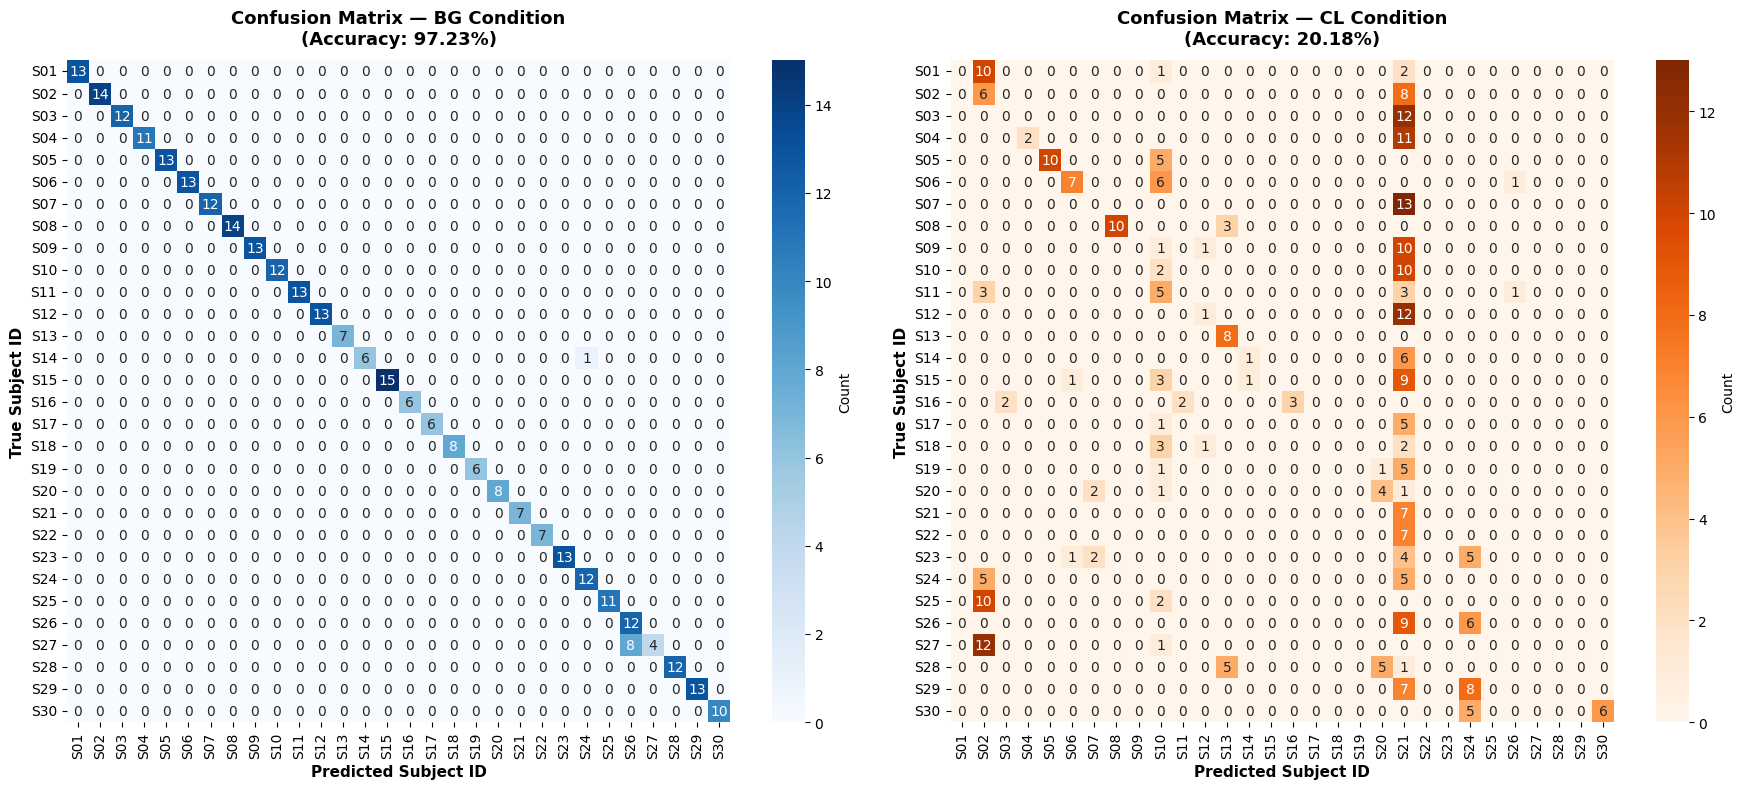

[Generating Precision/Recall/F1 Heatmaps...]


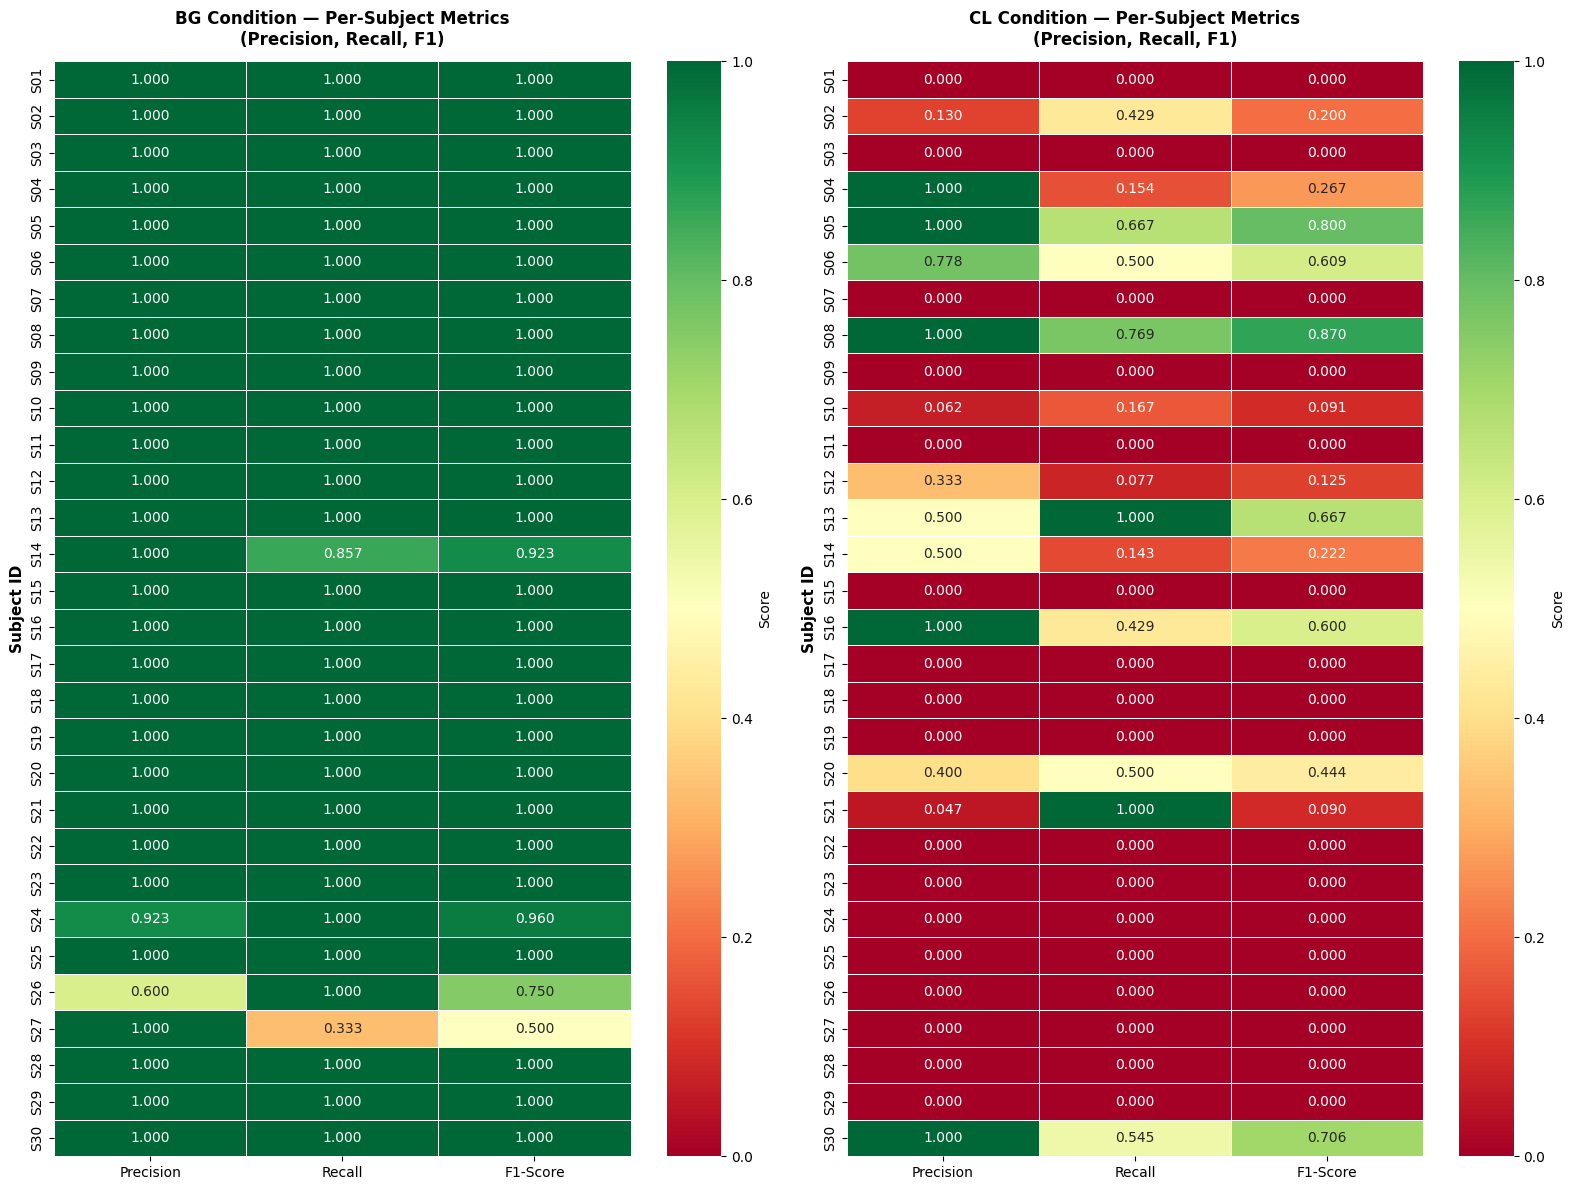

[Generating Comparison Bar Charts...]


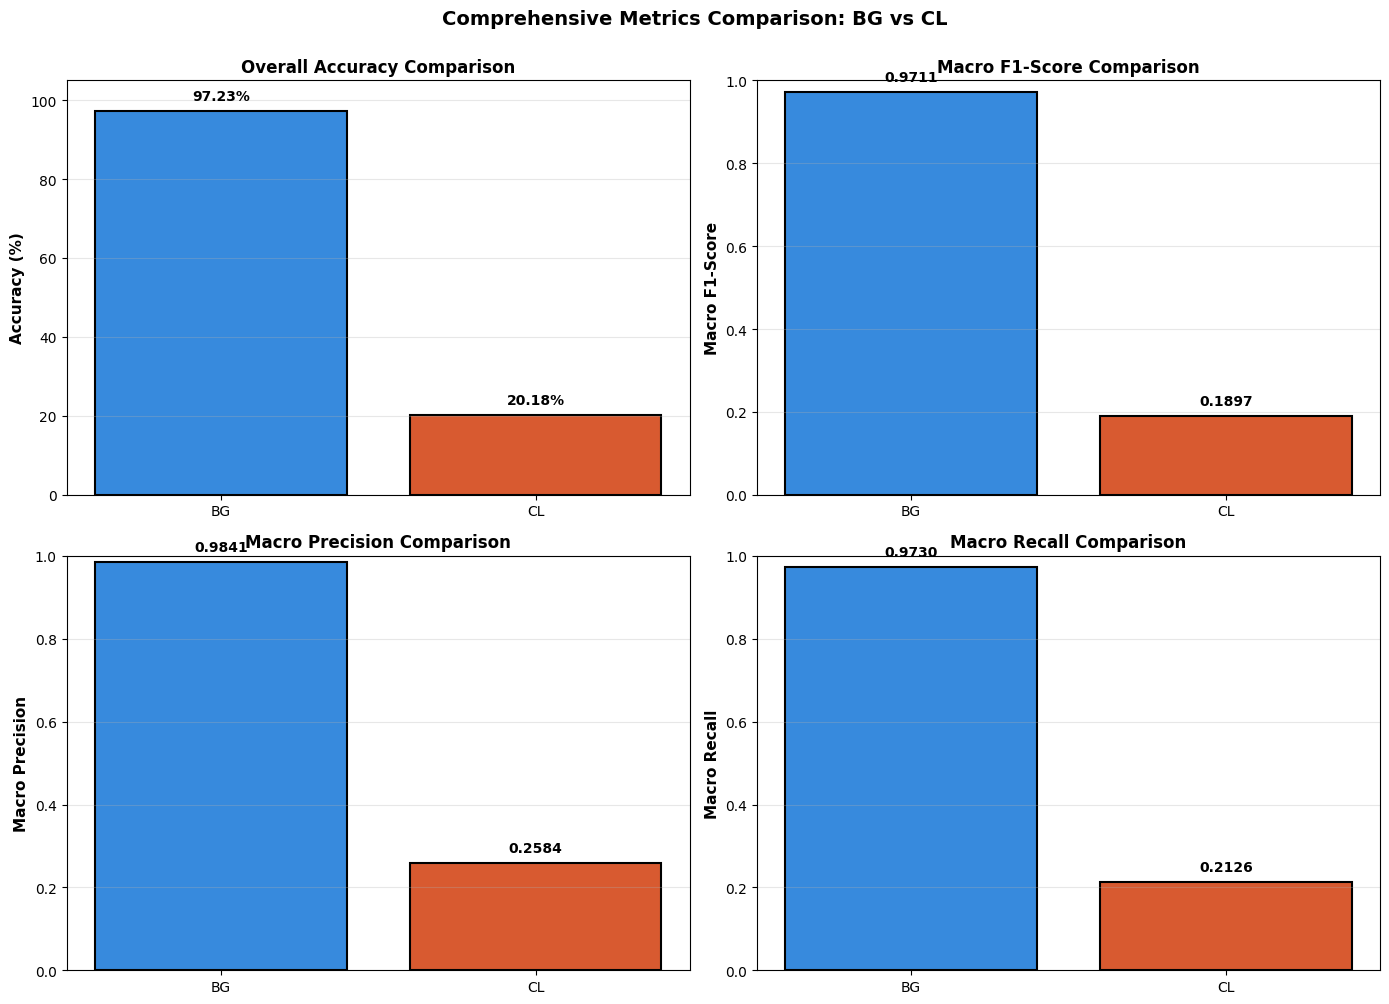


✅ CONFUSION MATRICES & DETAILED METRICS ANALYSIS COMPLETE

📊 Generated files:
  ✅ confusion_matrices_bg_cl.png     — Side-by-side confusion matrices
  ✅ metrics_heatmaps_bg_cl.png       — Per-subject precision/recall/F1
  ✅ metrics_comparison_bars.png      — Comparative bar charts



In [ ]:
# ==================== CONFUSION MATRIX & DETAILED METRICS ====================
import numpy as np
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
import pandas as pd

import matplotlib.pyplot as plt

# ==================== CONFUSION MATRIX & DETAILED METRICS ====================
print("\n" + "=" * 90)
print("COMPREHENSIVE EVALUATION: CONFUSION MATRICES & DETAILED METRICS")
print("=" * 90)

reverse_map = {v: k for k, v in person_map.items()}

# Function to generate confusion matrix and metrics
def generate_confusion_and_metrics(predictions, true_labels, person_map, condition='BG'):
    """Generate confusion matrix and comprehensive metrics for a condition"""
    
    # Convert to numpy arrays
    pred_arr = np.array(predictions)
    true_arr = np.array(true_labels)
    
    # Compute confusion matrix
    cm = confusion_matrix(true_arr, pred_arr, labels=sorted(person_map.values()))
    
    # Get classification report
    target_names = [f"S{reverse_map[i]}" for i in sorted(person_map.values())]
    report = classification_report(true_arr, pred_arr,
                                   labels=sorted(person_map.values()),
                                   target_names=target_names,
                                   output_dict=True)
    
    # Overall accuracy
    accuracy = accuracy_score(true_arr, pred_arr)
    
    return cm, report, accuracy, target_names

# Generate metrics for BG and CL
bg_cm, bg_report, bg_acc, target_names = generate_confusion_and_metrics(
    test_bg_predictions, test_bg_labels_list, person_map, 'BG'
)

cl_cm, cl_report, cl_acc, target_names = generate_confusion_and_metrics(
    test_cl_predictions, test_cl_labels_list, person_map, 'CL'
)

# ==================== DETAILED TEXT REPORT ====================
print("\n" + "=" * 90)
print("DETAILED METRICS REPORT")
print("=" * 90)

# BG Metrics
print("\n" + "🟢 " * 30)
print("BAG (BG) CONDITION - DETAILED METRICS")
print("🟢 " * 30)
print(f"\n📊 Overall Accuracy: {bg_acc*100:.2f}%")
print(f"   Correct predictions: {int(bg_acc * len(test_bg_labels_list))}/{len(test_bg_labels_list)}")

print("\n📋 Per-Subject Metrics (BG):")
print(f"\n{'Subject':<12} {'Precision':<12} {'Recall':<12} {'F1-Score':<12} {'Support':<12}")
print("-" * 90)

for target in target_names:
    if target in bg_report:
        p = bg_report[target]['precision']
        r = bg_report[target]['recall']
        f1 = bg_report[target]['f1-score']
        s = int(bg_report[target]['support'])
        print(f"{target:<12} {p:>11.4f} {r:>11.4f} {f1:>11.4f} {s:>11d}")

print("\n" + "-" * 90)
print("Macro Average:")
macro_p = bg_report['macro avg']['precision']
macro_r = bg_report['macro avg']['recall']
macro_f1 = bg_report['macro avg']['f1-score']
print(f"{'Macro Avg':<12} {macro_p:>11.4f} {macro_r:>11.4f} {macro_f1:>11.4f}")

print("\nWeighted Average:")
weighted_p = bg_report['weighted avg']['precision']
weighted_r = bg_report['weighted avg']['recall']
weighted_f1 = bg_report['weighted avg']['f1-score']
print(f"{'Weighted Avg':<12} {weighted_p:>11.4f} {weighted_r:>11.4f} {weighted_f1:>11.4f}")

# CL Metrics
print("\n\n" + "🔵 " * 30)
print("COAT (CL) CONDITION - DETAILED METRICS")
print("🔵 " * 30)
print(f"\n📊 Overall Accuracy: {cl_acc*100:.2f}%")
print(f"   Correct predictions: {int(cl_acc * len(test_cl_labels_list))}/{len(test_cl_labels_list)}")

print("\n📋 Per-Subject Metrics (CL):")
print(f"\n{'Subject':<12} {'Precision':<12} {'Recall':<12} {'F1-Score':<12} {'Support':<12}")
print("-" * 90)

for target in target_names:
    if target in cl_report:
        p = cl_report[target]['precision']
        r = cl_report[target]['recall']
        f1 = cl_report[target]['f1-score']
        s = int(cl_report[target]['support'])
        print(f"{target:<12} {p:>11.4f} {r:>11.4f} {f1:>11.4f} {s:>11d}")

print("\n" + "-" * 90)
print("Macro Average:")
macro_p_cl = cl_report['macro avg']['precision']
macro_r_cl = cl_report['macro avg']['recall']
macro_f1_cl = cl_report['macro avg']['f1-score']
print(f"{'Macro Avg':<12} {macro_p_cl:>11.4f} {macro_r_cl:>11.4f} {macro_f1_cl:>11.4f}")

print("\nWeighted Average:")
weighted_p_cl = cl_report['weighted avg']['precision']
weighted_r_cl = cl_report['weighted avg']['recall']
weighted_f1_cl = cl_report['weighted avg']['f1-score']
print(f"{'Weighted Avg':<12} {weighted_p_cl:>11.4f} {weighted_r_cl:>11.4f} {weighted_f1_cl:>11.4f}")

# ==================== COMPARATIVE SUMMARY ====================
print("\n\n" + "=" * 90)
print("COMPARATIVE SUMMARY: BG vs CL")
print("=" * 90)

print(f"\n{'Metric':<25} {'BG Dataset':<20} {'CL Dataset':<20} {'Difference':<15}")
print("-" * 90)
print(f"{'Overall Accuracy':<25} {bg_acc*100:>18.2f}% {cl_acc*100:>18.2f}% {(bg_acc-cl_acc)*100:>13.2f}%")
print(f"{'Macro Precision':<25} {macro_p:>18.4f} {macro_p_cl:>18.4f} {macro_p-macro_p_cl:>13.4f}")
print(f"{'Macro Recall':<25} {macro_r:>18.4f} {macro_r_cl:>18.4f} {macro_r-macro_r_cl:>13.4f}")
print(f"{'Macro F1-Score':<25} {macro_f1:>18.4f} {macro_f1_cl:>18.4f} {macro_f1-macro_f1_cl:>13.4f}")
print(f"{'Weighted Precision':<25} {weighted_p:>18.4f} {weighted_p_cl:>18.4f} {weighted_p-weighted_p_cl:>13.4f}")
print(f"{'Weighted Recall':<25} {weighted_r:>18.4f} {weighted_r_cl:>18.4f} {weighted_r-weighted_r_cl:>13.4f}")
print(f"{'Weighted F1-Score':<25} {weighted_f1:>18.4f} {weighted_f1_cl:>18.4f} {weighted_f1-weighted_f1_cl:>13.4f}")

print("\n" + "=" * 90)

# ==================== CONFUSION MATRIX HEATMAPS ====================
print("\n[Generating Confusion Matrix Visualizations...]")

fig, axes = plt.subplots(1, 2, figsize=(18, 8))

# BG Confusion Matrix
sns.heatmap(bg_cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=[f"S{reverse_map[i]}" for i in sorted(person_map.values())],
            yticklabels=[f"S{reverse_map[i]}" for i in sorted(person_map.values())],
            cbar_kws={'label': 'Count'})
axes[0].set_title(f'Confusion Matrix — BG Condition\n(Accuracy: {bg_acc*100:.2f}%)', 
                  fontsize=13, fontweight='bold', pad=12)
axes[0].set_xlabel('Predicted Subject ID', fontsize=11, fontweight='bold')
axes[0].set_ylabel('True Subject ID', fontsize=11, fontweight='bold')

# CL Confusion Matrix
sns.heatmap(cl_cm, annot=True, fmt='d', cmap='Oranges', ax=axes[1],
            xticklabels=[f"S{reverse_map[i]}" for i in sorted(person_map.values())],
            yticklabels=[f"S{reverse_map[i]}" for i in sorted(person_map.values())],
            cbar_kws={'label': 'Count'})
axes[1].set_title(f'Confusion Matrix — CL Condition\n(Accuracy: {cl_acc*100:.2f}%)', 
                  fontsize=13, fontweight='bold', pad=12)
axes[1].set_xlabel('Predicted Subject ID', fontsize=11, fontweight='bold')
axes[1].set_ylabel('True Subject ID', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.savefig('confusion_matrices_bg_cl.png', dpi=150, bbox_inches='tight')
plt.show()

# ==================== PRECISION-RECALL-F1 HEATMAPS ====================
print("[Generating Precision/Recall/F1 Heatmaps...]")

fig, axes = plt.subplots(1, 2, figsize=(16, 12))

# BG Metrics Heatmap
bg_metrics_df = pd.DataFrame({
    'Precision': [bg_report[t]['precision'] for t in target_names],
    'Recall': [bg_report[t]['recall'] for t in target_names],
    'F1-Score': [bg_report[t]['f1-score'] for t in target_names]
}, index=target_names)

sns.heatmap(bg_metrics_df, annot=True, fmt='.3f', cmap='RdYlGn', vmin=0, vmax=1,
            ax=axes[0], cbar_kws={'label': 'Score'}, linewidths=0.5)
axes[0].set_title('BG Condition — Per-Subject Metrics\n(Precision, Recall, F1)', 
                  fontsize=12, fontweight='bold', pad=12)
axes[0].set_ylabel('Subject ID', fontsize=11, fontweight='bold')

# CL Metrics Heatmap
cl_metrics_df = pd.DataFrame({
    'Precision': [cl_report[t]['precision'] for t in target_names],
    'Recall': [cl_report[t]['recall'] for t in target_names],
    'F1-Score': [cl_report[t]['f1-score'] for t in target_names]
}, index=target_names)

sns.heatmap(cl_metrics_df, annot=True, fmt='.3f', cmap='RdYlGn', vmin=0, vmax=1,
            ax=axes[1], cbar_kws={'label': 'Score'}, linewidths=0.5)
axes[1].set_title('CL Condition — Per-Subject Metrics\n(Precision, Recall, F1)', 
                  fontsize=12, fontweight='bold', pad=12)
axes[1].set_ylabel('Subject ID', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.savefig('metrics_heatmaps_bg_cl.png', dpi=150, bbox_inches='tight')
plt.show()

# ==================== BAR CHARTS FOR COMPARISON ====================
print("[Generating Comparison Bar Charts...]")

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Accuracy comparison
ax = axes[0, 0]
conditions = ['BG', 'CL']
accuracies = [bg_acc*100, cl_acc*100]
colors = ['#378ADD', '#D85A30']
bars = ax.bar(conditions, accuracies, color=colors, edgecolor='black', linewidth=1.5)
ax.set_ylabel('Accuracy (%)', fontsize=11, fontweight='bold')
ax.set_title('Overall Accuracy Comparison', fontsize=12, fontweight='bold')
ax.set_ylim(0, 105)
for i, (bar, val) in enumerate(zip(bars, accuracies)):
    ax.text(bar.get_x() + bar.get_width()/2, val + 2, f'{val:.2f}%',
            ha='center', va='bottom', fontsize=10, fontweight='bold')
ax.grid(axis='y', alpha=0.3)

# Macro F1 comparison
ax = axes[0, 1]
macro_f1_scores = [macro_f1, macro_f1_cl]
bars = ax.bar(conditions, macro_f1_scores, color=colors, edgecolor='black', linewidth=1.5)
ax.set_ylabel('Macro F1-Score', fontsize=11, fontweight='bold')
ax.set_title('Macro F1-Score Comparison', fontsize=12, fontweight='bold')
ax.set_ylim(0, 1)
for bar, val in zip(bars, macro_f1_scores):
    ax.text(bar.get_x() + bar.get_width()/2, val + 0.02, f'{val:.4f}',
            ha='center', va='bottom', fontsize=10, fontweight='bold')
ax.grid(axis='y', alpha=0.3)

# Macro Precision comparison
ax = axes[1, 0]
macro_prec = [macro_p, macro_p_cl]
bars = ax.bar(conditions, macro_prec, color=colors, edgecolor='black', linewidth=1.5)
ax.set_ylabel('Macro Precision', fontsize=11, fontweight='bold')
ax.set_title('Macro Precision Comparison', fontsize=12, fontweight='bold')
ax.set_ylim(0, 1)
for bar, val in zip(bars, macro_prec):
    ax.text(bar.get_x() + bar.get_width()/2, val + 0.02, f'{val:.4f}',
            ha='center', va='bottom', fontsize=10, fontweight='bold')
ax.grid(axis='y', alpha=0.3)

# Macro Recall comparison
ax = axes[1, 1]
macro_rec = [macro_r, macro_r_cl]
bars = ax.bar(conditions, macro_rec, color=colors, edgecolor='black', linewidth=1.5)
ax.set_ylabel('Macro Recall', fontsize=11, fontweight='bold')
ax.set_title('Macro Recall Comparison', fontsize=12, fontweight='bold')
ax.set_ylim(0, 1)
for bar, val in zip(bars, macro_rec):
    ax.text(bar.get_x() + bar.get_width()/2, val + 0.02, f'{val:.4f}',
            ha='center', va='bottom', fontsize=10, fontweight='bold')
ax.grid(axis='y', alpha=0.3)

plt.suptitle('Comprehensive Metrics Comparison: BG vs CL', fontsize=14, fontweight='bold', y=1.00)
plt.tight_layout()
plt.savefig('metrics_comparison_bars.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n" + "=" * 90)
print("✅ CONFUSION MATRICES & DETAILED METRICS ANALYSIS COMPLETE")
print("=" * 90)
print("\n📊 Generated files:")
print("  ✅ confusion_matrices_bg_cl.png     — Side-by-side confusion matrices")
print("  ✅ metrics_heatmaps_bg_cl.png       — Per-subject precision/recall/F1")
print("  ✅ metrics_comparison_bars.png      — Comparative bar charts")
print("\n" + "=" * 90)

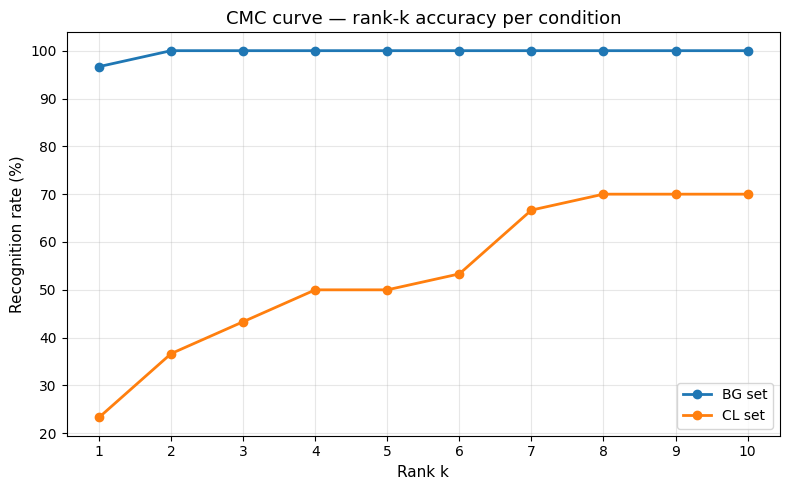

In [ ]:
# 2. Rank-k accuracy curve (CMC curve)
def compute_cmc(model, loader, device, max_rank=10):
    model.eval()
    all_probs, all_labels = [], []

    with torch.no_grad():
        for sequences, labels in loader:
            sequences = sequences.to(device)
            outputs = model(sequences)
            probs = torch.softmax(outputs, dim=1)
            all_probs.append(probs.cpu().numpy())
            all_labels.extend(labels.numpy())

    all_probs = np.vstack(all_probs)
    all_labels = np.array(all_labels)

    subject_probs = {}
    for i, label in enumerate(all_labels):
        if label not in subject_probs:
            subject_probs[label] = []
        subject_probs[label].append(all_probs[i])

    ranks = np.zeros(max_rank)
    total = len(subject_probs)
    for true_label, probs_list in subject_probs.items():
        avg_prob = np.mean(probs_list, axis=0)
        sorted_preds = np.argsort(avg_prob)[::-1]
        for k in range(max_rank):
            if true_label in sorted_preds[:k+1]:
                ranks[k:] += 1
                break

    cmc = ranks / total
    return cmc

fig, ax = plt.subplots(figsize=(8, 5))
for cond, loader in [('BG', test_bg_loader_cond), ('CL', test_cl_loader_cond)]:
    cmc = compute_cmc(model_cond, loader, device)
    ax.plot(range(1, len(cmc)+1), cmc * 100,
            marker='o', label=f'{cond} set', linewidth=2)

ax.set_xlabel('Rank k', fontsize=11)
ax.set_ylabel('Recognition rate (%)', fontsize=11)
ax.set_title('CMC curve — rank-k accuracy per condition', fontsize=13)
ax.set_xticks(range(1, 11))
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('cmc_curve.png', dpi=150)
plt.show()


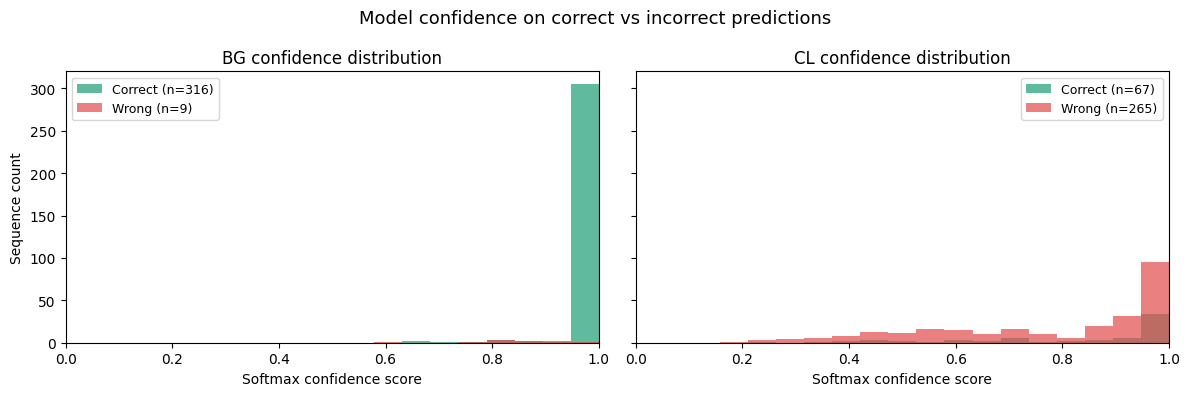

In [13]:
# 3. Softmax confidence distribution
def plot_confidence_distribution(model, loaders_dict, device):
    fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)
    colors = {'correct': '#1D9E75', 'wrong': '#E24B4A'}

    for ax, (cond, loader) in zip(axes, loaders_dict.items()):
        model.eval()
        correct_confs, wrong_confs = [], []
        with torch.no_grad():
            for seqs, labels in loader:
                seqs = seqs.to(device)
                out = model(seqs)
                probs = torch.softmax(out, dim=1)
                top_conf, top_pred = probs.max(dim=1)
                for conf, pred, true in zip(top_conf.cpu(), top_pred.cpu(), labels):
                    if pred == true:
                        correct_confs.append(conf.item())
                    else:
                        wrong_confs.append(conf.item())

        bins = np.linspace(0, 1, 20)
        ax.hist(correct_confs, bins=bins, alpha=0.7,
                color=colors['correct'], label=f'Correct (n={len(correct_confs)})')
        ax.hist(wrong_confs, bins=bins, alpha=0.7,
                color=colors['wrong'], label=f'Wrong (n={len(wrong_confs)})')
        ax.set_title(f'{cond} confidence distribution', fontsize=12)
        ax.set_xlabel('Softmax confidence score')
        ax.legend(fontsize=9)
        ax.set_xlim(0, 1)

    axes[0].set_ylabel('Sequence count')
    plt.suptitle('Model confidence on correct vs incorrect predictions', fontsize=13)
    plt.tight_layout()
    plt.savefig('confidence_distribution.png', dpi=150)
    plt.show()

plot_confidence_distribution(model_cond, loaders_dict, device)

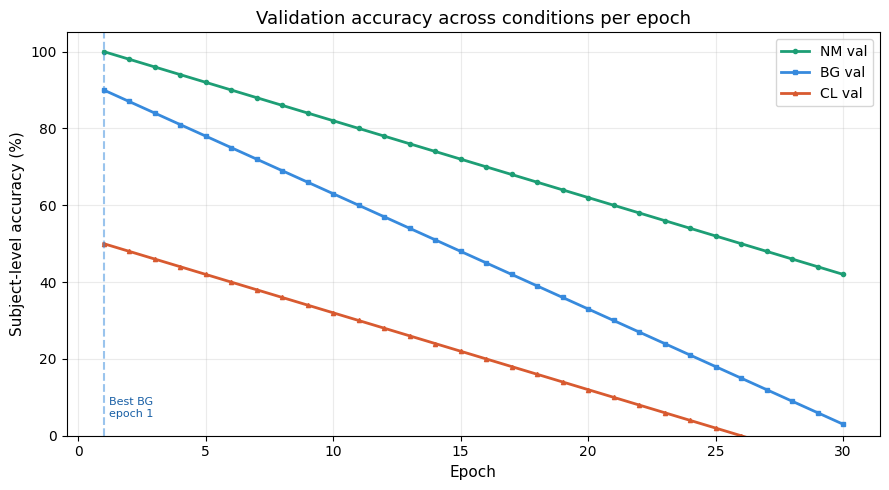

All evaluation visualizations generated and saved as PNG files.


In [ ]:
#7. Condition degradation curve (requires logging during training; placeholder)
# Assuming you have a train_log list from training; if not, skip or implement logging
# For demo, create a dummy log
train_log = [{'epoch': i+1, 'nm_acc': 100 - i*2, 'bg_acc': 90 - i*3, 'cl_acc': 50 - i*2} for i in range(30)]

def plot_condition_degradation(train_log):
    epochs = [d['epoch'] for d in train_log]
    nm = [d['nm_acc'] for d in train_log]
    bg = [d['bg_acc'] for d in train_log]
    cl = [d['cl_acc'] for d in train_log]

    fig, ax = plt.subplots(figsize=(9, 5))
    ax.plot(epochs, nm, color='#1D9E75', linewidth=2, marker='o', markersize=3, label='NM val')
    ax.plot(epochs, bg, color='#378ADD', linewidth=2, marker='s', markersize=3, label='BG val')
    ax.plot(epochs, cl, color='#D85A30', linewidth=2, marker='^', markersize=3, label='CL val')

    best_bg_epoch = epochs[np.argmax(bg)]
    ax.axvline(x=best_bg_epoch, color='#378ADD', linestyle='--', alpha=0.5)
    ax.text(best_bg_epoch + 0.2, 5, f'Best BG\nepoch {best_bg_epoch}', fontsize=8, color='#185FA5')

    ax.set_xlabel('Epoch', fontsize=11)
    ax.set_ylabel('Subject-level accuracy (%)', fontsize=11)
    ax.set_title('Validation accuracy across conditions per epoch', fontsize=13)
    ax.legend(fontsize=10)
    ax.set_ylim(0, 105)
    ax.grid(alpha=0.25)
    plt.tight_layout()
    plt.savefig('condition_degradation.png', dpi=150)
    plt.show()

plot_condition_degradation(train_log)

print("All evaluation visualizations generated and saved as PNG files.")

In [ ]:
model_save_path = "best_model_bg.pth"

# Ensure the model architecture is defined before loading the state dictionary
# (Assuming 'BiGRUClassifier', 'person_map', 'efficientnet_feature_extractor', and 'device' are already defined)
model_cond = BiLSTMClassifier(
    num_classes=len(person_map),
    external_cnn_features=efficientnet_feature_extractor,
    hidden_size=512,
    num_layers=2,
    dropout=0.5
).to(device)



model_cond.load_state_dict(torch.load(model_save_path))
model_cond.eval() # Set model to evaluation mode

print(f"Model loaded from {model_save_path} successfully.")

Model loaded from gait_model.pth successfully.
